In [48]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

In [49]:
title = "# Solutions to random variables and probability distributions"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Solutions to random variables and probability distributions

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

## Exercise 1: Inverse transform sampling

The PDF is
$$
    p(x) = \begin{cases}
                \frac{1}{2}\sin x & 0 \le x \le \pi \\
                0 & \text{otherwise}
            \end{cases}
$$

### 1.1 CDF

Integrating the PDF, the CDF is
$$
    F(x) = \int_{-\infty}^{x} p(x')\,\mathrm{d} x' = \begin{cases}
                0 & x < 0 \\
                \frac{1}{2}\left(1 - \cos x\right) & 0 \le x \le \pi \\
                1 & x > \pi
            \end{cases}
$$

Define the PDF and CDF, and plot them:

In [50]:
def sin_distr_pdf(x):
    x = np.asarray(x, dtype=float)
    return np.where((0 <= x) & (x <= np.pi), 0.5*np.sin(x), 0.0)

def sin_distr_cdf(x):
    x = np.asarray(x, dtype=float)
    cdf = 0.5 - 0.5*np.cos(x)          # formula for 0 <= x <= pi
    cdf = np.where(x < 0, 0.0, cdf)     # 0 below the support
    cdf = np.where(x > np.pi, 1.0, cdf) # 1 above the support
    return cdf

Text(0, 0.5, 'CDF')

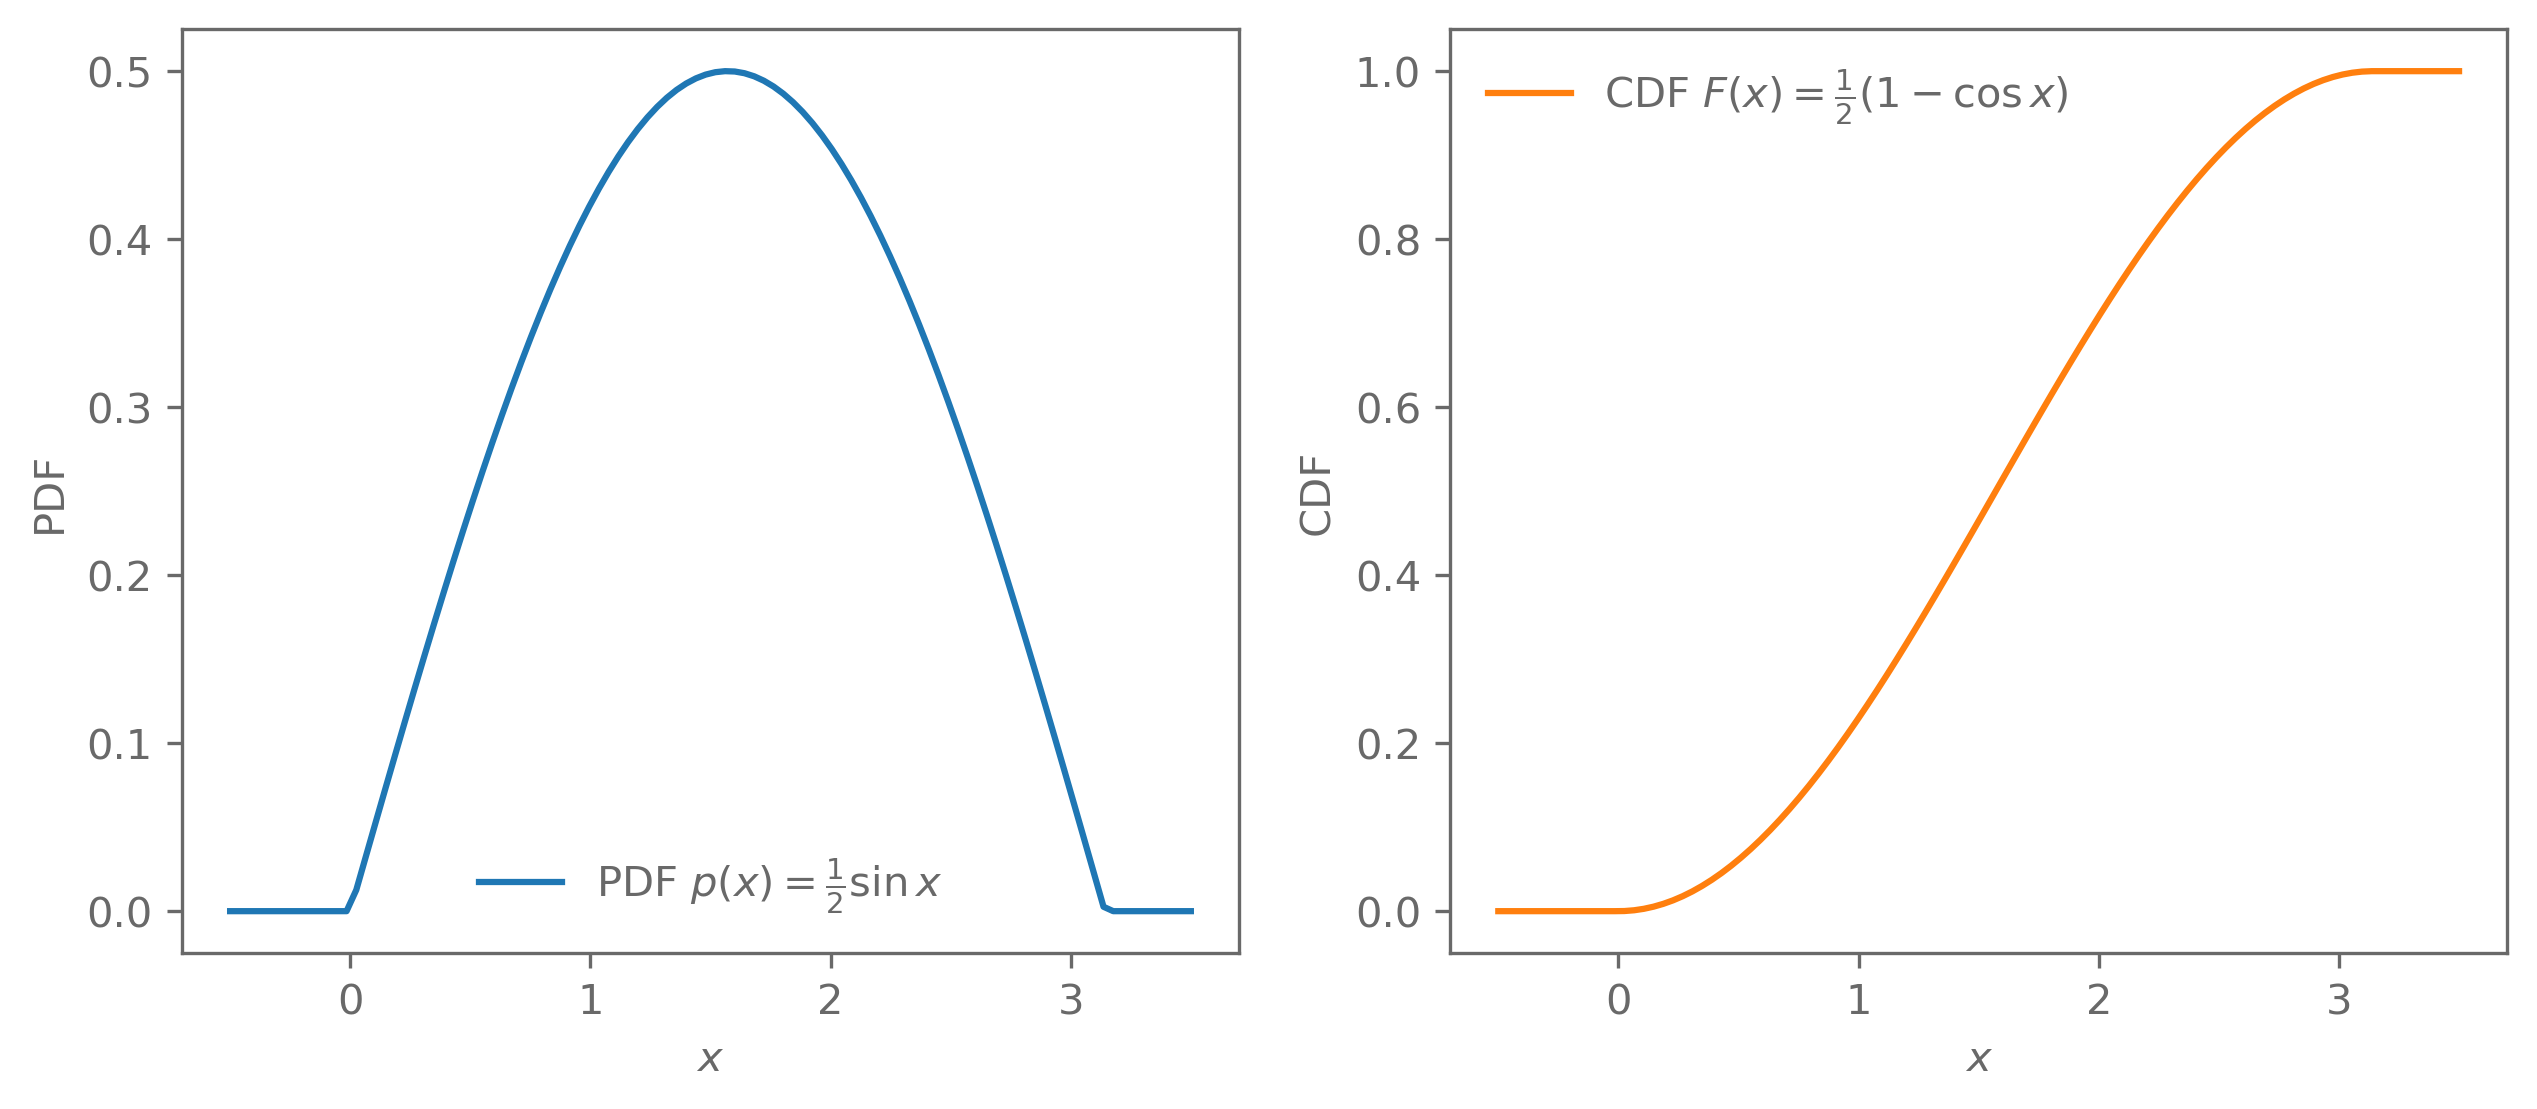

In [51]:
grid = np.linspace(-0.5, 3.5, 100)

fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(10, 4))

ax_pdf.plot(grid, sin_distr_pdf(grid), c="C0", label=r"PDF $p(x)=\frac{1}{2}\sin x$")
ax_pdf.legend(frameon=False)
ax_pdf.set_xlabel("$x$")
ax_pdf.set_ylabel("PDF")

ax_cdf.plot(grid, sin_distr_cdf(grid), c="C1", label=r"CDF $F(x)=\frac{1}{2}(1-\cos x)$")
ax_cdf.legend(frameon=False)
ax_cdf.set_xlabel("$x$")
ax_cdf.set_ylabel("CDF")

### 1.2 Inverse CDF and sampling

Setting $u = F(x)$ and solving for $x$ gives the inverse CDF
$$
    F^{-1}(u) = \arccos(1 - 2u), \quad u \in [0, 1].
$$

If $U \sim \mathcal{U}(0, 1)$, then $X = F^{-1}(U)$ has PDF $p$. So we draw uniform samples and transform them with $F^{-1}$:

In [52]:
def sin_distr_cdf_inv(u):
    u = np.asarray(u, dtype=float)
    if np.any((u < 0) | (1 < u)):
        raise ValueError("u outside domain [0, 1]")
    return np.arccos(1 - 2*u)

rng = np.random.default_rng(42)

n = 10000
u = rng.uniform(size=n)
samples = sin_distr_cdf_inv(u)

### 1.3 Comparing the samples with the PDF

A density-normalised histogram of the samples should follow the PDF $p(x)$:

Text(0, 0.5, 'Density')

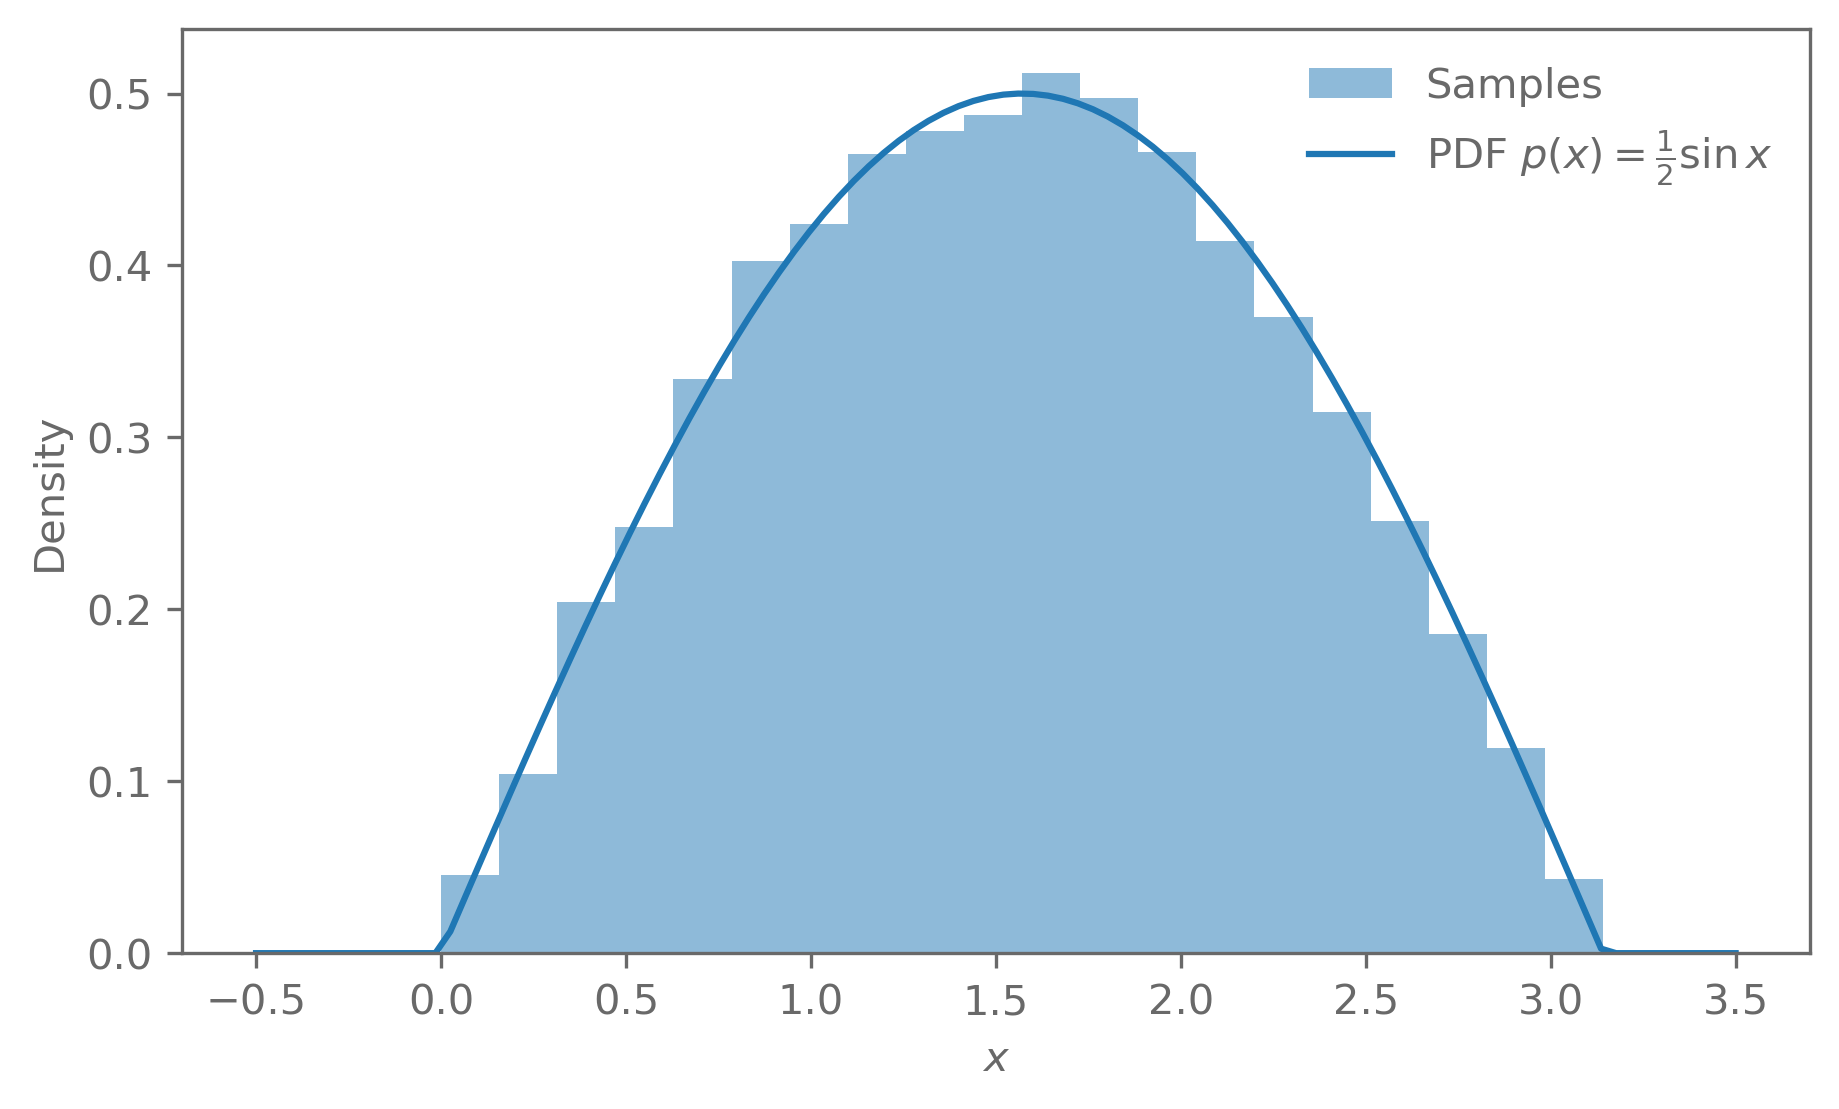

In [53]:
grid = np.linspace(-0.5, 3.5, 100)

plt.hist(samples, bins=np.linspace(0, np.pi, 21), density=True, alpha=0.5, label="Samples")
plt.plot(grid, sin_distr_pdf(grid), c="C0", label=r"PDF $p(x)=\frac{1}{2}\sin x$")
plt.legend(frameon=False)
plt.xlabel("$x$")
plt.ylabel("Density")

## Exercise 2: Mean and variance

We use the definition of the expectation, $\E[f(x)] = \int_{-\infty}^\infty f(x)\, p(x) \dd x$, and the normalisation of the PDF, $\int_{-\infty}^\infty p(x) \dd x = 1$.

**Mean**

1. $\E[x + a] = \int (x + a)\, p(x) \dd x = \int x\, p(x) \dd x + a \int p(x) \dd x = \mu + a$
2. $\E[cx] = \int c\,x\, p(x) \dd x = c \int x\, p(x) \dd x = c\mu$

More generally, because the integral is linear, $\E[c f(x) + d\, g(x)] = c\,\E[f(x)] + d\,\E[g(x)]$ for constants $c$ and $d$.

**Variance**

3. Expanding the square and using linearity, with $\E[x] = \mu$ a constant:
$$
    \Var[x] = \E[(x - \mu)^2] = \E[x^2 - 2\mu x + \mu^2] = \E[x^2] - 2\mu\,\E[x] + \mu^2 = \E[x^2] - \mu^2 = \E[x^2] - \E[x]^2
$$
4. Using result 1, $\E[x + a] = \mu + a$, so
$$
    \Var[x + a] = \E\left[\big((x + a) - (\mu + a)\big)^2\right] = \E[(x - \mu)^2] = \sigma^2
$$
5. Using result 2, $\E[cx] = c\mu$, so
$$
    \Var[cx] = \E[(cx - c\mu)^2] = c^2\, \E[(x - \mu)^2] = c^2\sigma^2
$$

## Exercise 3: Poisson distribution

### 3.1 Simulation with uniform samples in small intervals

Each $X_i \sim \Uniform(0, 1)$ falls into an interval of width $\Delta x$ (here $[0, \Delta x)$) with probability $\Delta x$, independently of the others. We draw $n$ samples many times, count the number $K$ that fall into the interval each time, and compare the histogram of $K$ with the Poisson PMF with rate $\lambda = n\,\Delta x$. (Exactly, $K \sim \mathrm{Binomial}(n, p = \Delta x)$, which approaches the Poisson distribution for large $n$ and small $\Delta x$.)

Text(0, 0.5, '$\\Pr(K=k)$')

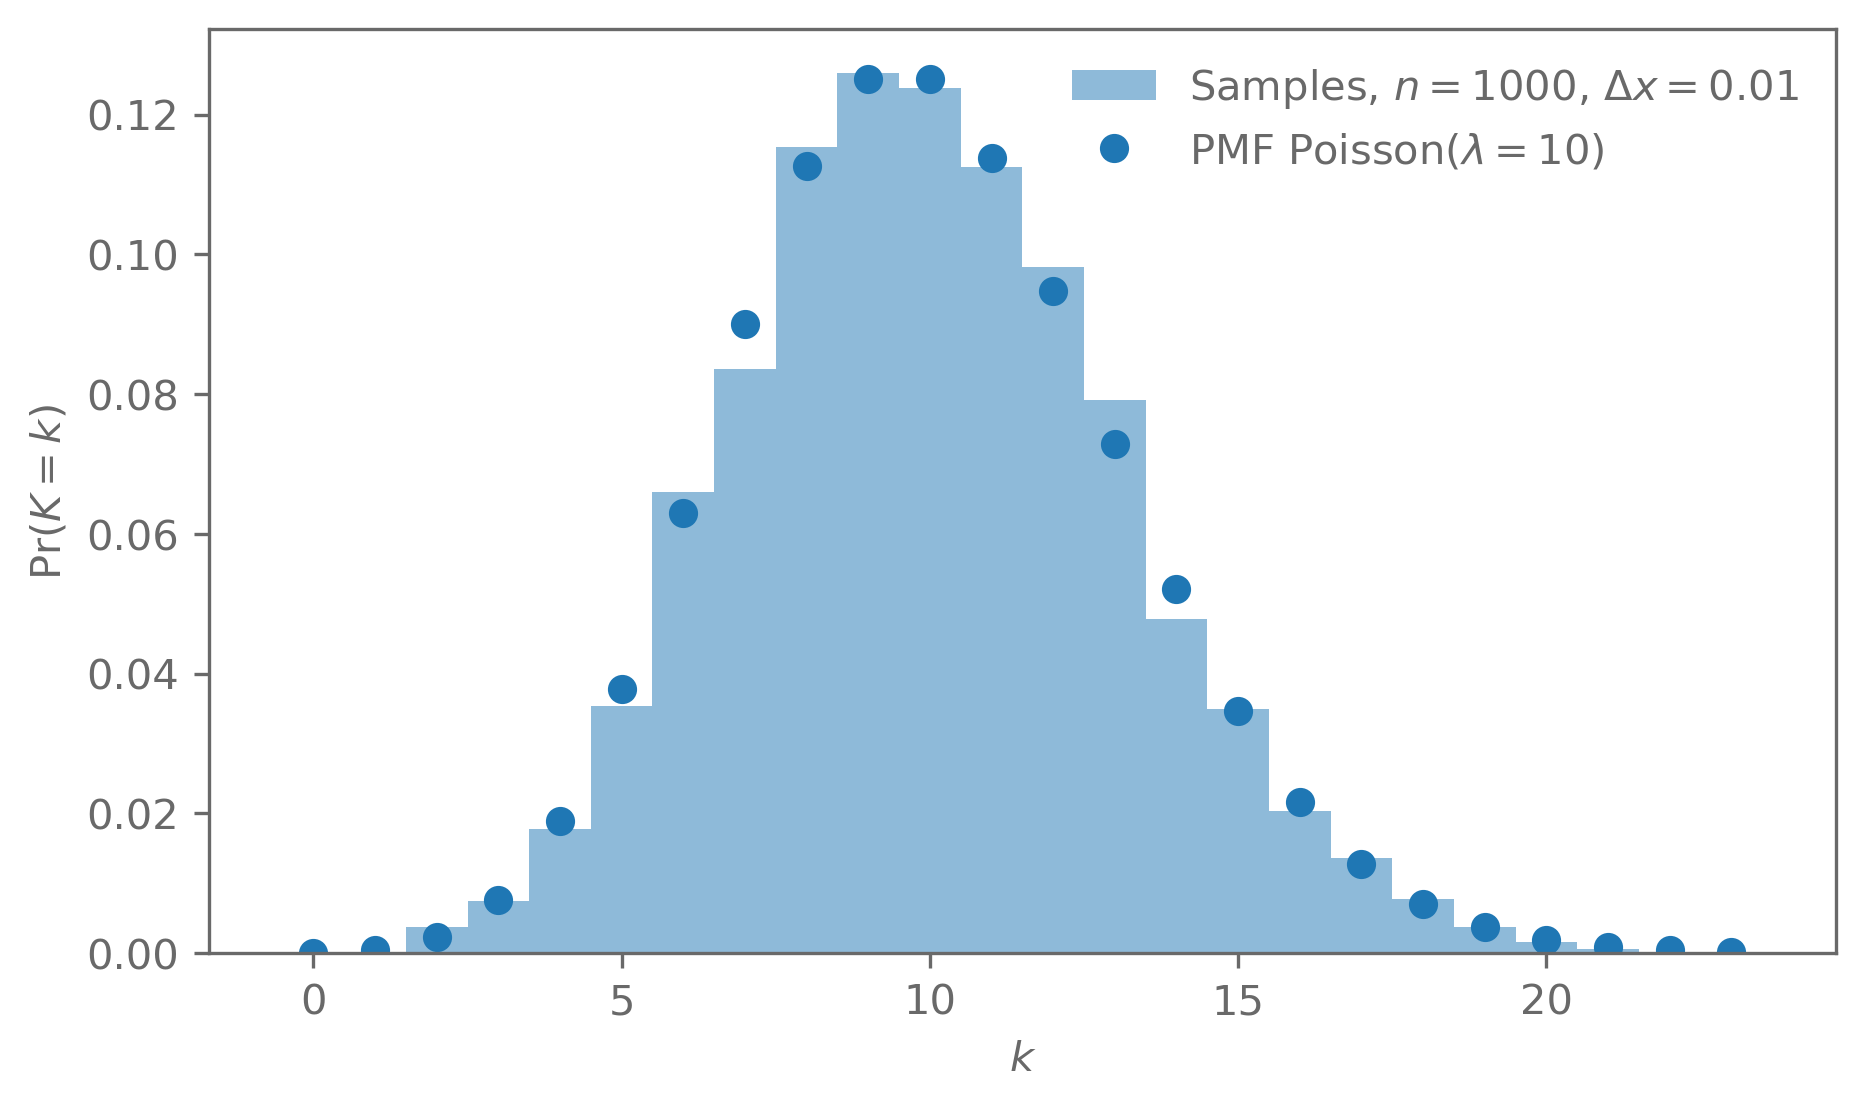

In [54]:
rng = np.random.default_rng(42)

n = 1000
bin_width = 0.01
rate = n*bin_width

n_repeat = 10000  # number of simulated experiments
x = rng.uniform(size=(n_repeat, n))
counts = np.sum(x < bin_width, axis=1)

k = np.arange(24)
plt.hist(counts, bins=np.arange(25)-0.5, density=True, alpha=0.5,
         label=rf"Samples, $n={n}$, $\Delta x={bin_width}$")
plt.plot(k, scipy.stats.poisson(rate).pmf(k), "o", c="C0", label=rf"PMF $\mathrm{{Poisson}}(\lambda={rate:g})$")
plt.legend(frameon=False)
plt.xlabel("$k$")
plt.ylabel(r"$\Pr(K=k)$")

The approximation breaks down when the interval is too wide. With $n = 20$ and $\Delta x = 0.5$ the rate is still $\lambda = 10$, but $\Delta x$ is no longer small: $K \sim \mathrm{Binomial}(n, p = \Delta x)$ has variance $np(1-p) = 5$, and is visibly narrower than the Poisson distribution with variance $\lambda = 10$:

Text(0, 0.5, '$\\Pr(K=k)$')

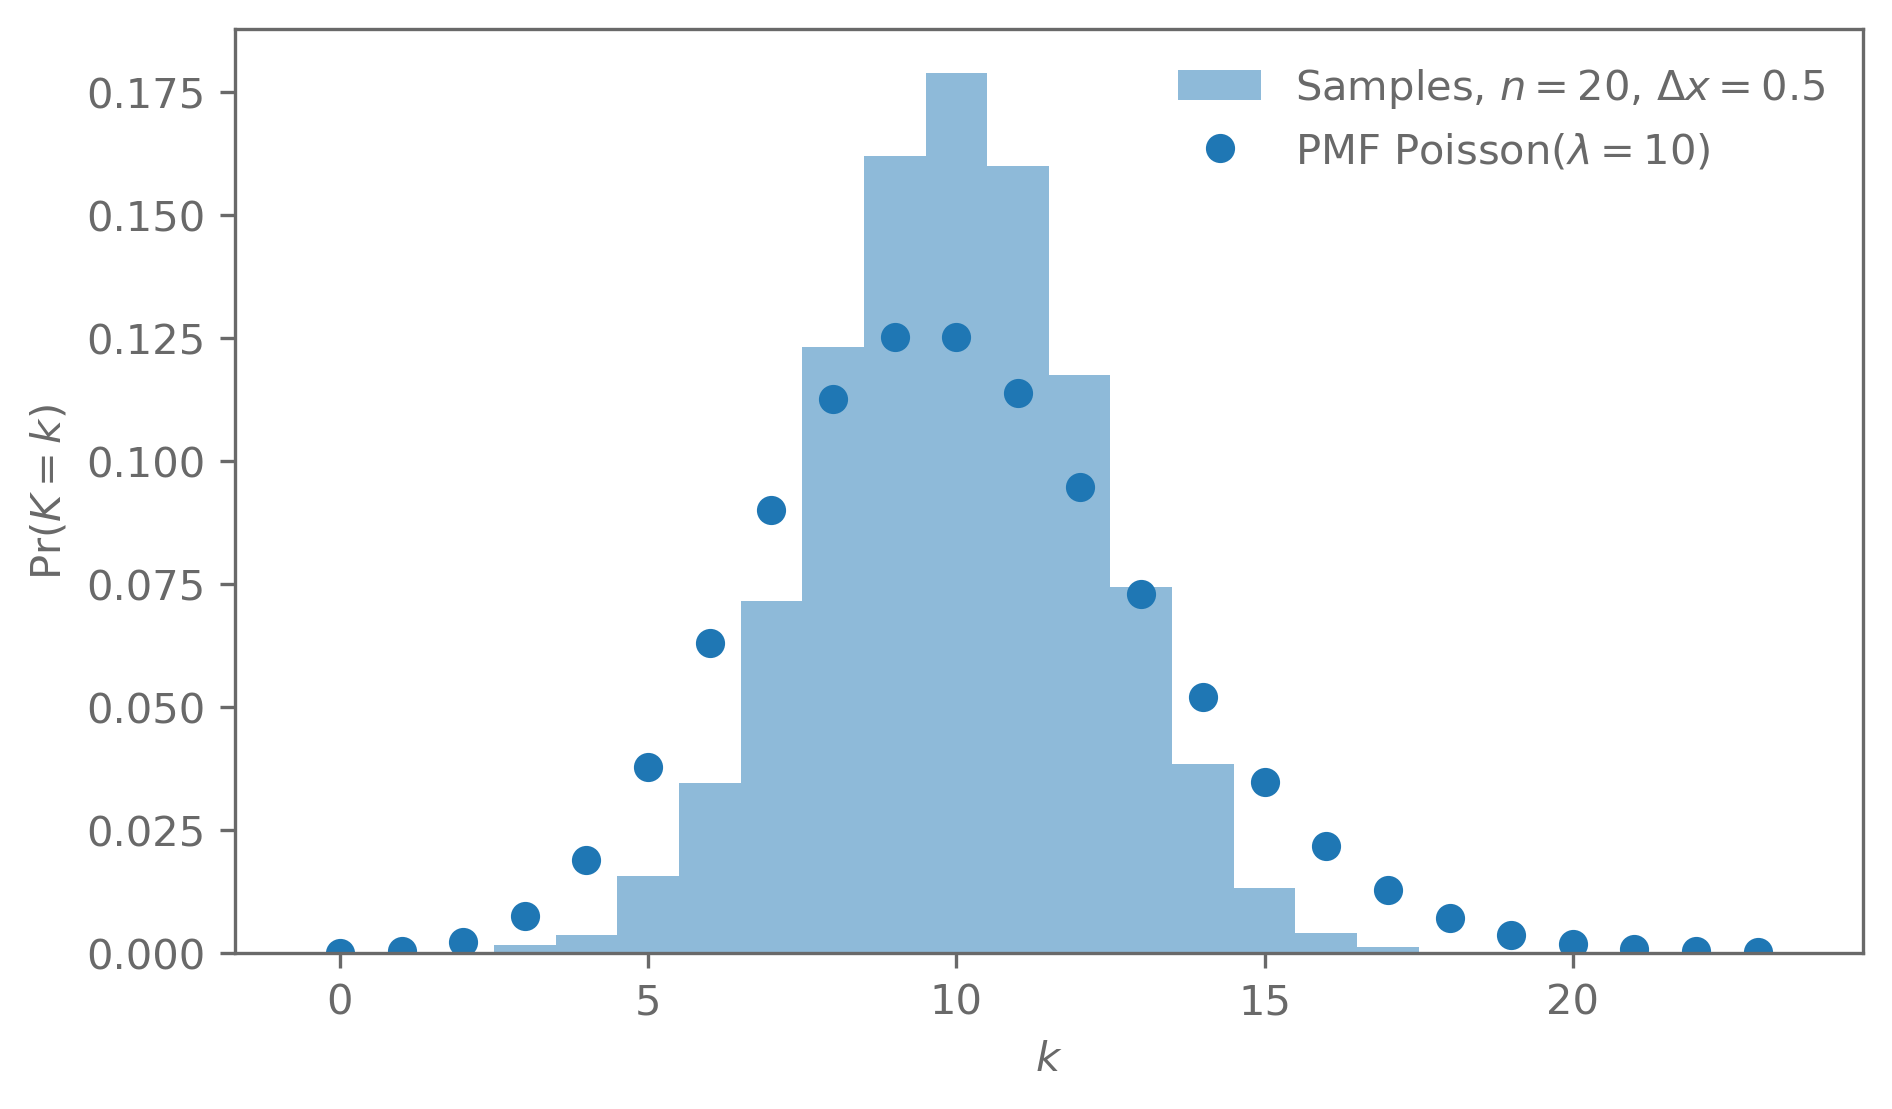

In [55]:
rng = np.random.default_rng(42)

n = 20
bin_width = 0.5
rate = n*bin_width

n_repeat = 10000  # number of simulated experiments
x = rng.uniform(size=(n_repeat, n))
counts = np.sum(x < bin_width, axis=1)

k = np.arange(24)
plt.hist(counts, bins=np.arange(25)-0.5, density=True, alpha=0.5,
         label=rf"Samples, $n={n}$, $\Delta x={bin_width}$")
plt.plot(k, scipy.stats.poisson(rate).pmf(k), "o", c="C0", label=rf"PMF $\mathrm{{Poisson}}(\lambda={rate:g})$")
plt.legend(frameon=False)
plt.xlabel("$k$")
plt.ylabel(r"$\Pr(K=k)$")

### 3.2 Derivation of the Poisson distribution from the binomial distribution

Let $\lambda$ be the rate of events, i.e., in an interval of length $T = 1$ we expect $\lambda$ events to occur.

Divide the interval into $n$ sub-intervals, fine enough that the probability of more than one event happening in the same sub-interval goes to 0. Each sub-interval then contains an event independently with probability $p = \frac{\lambda}{n}$, i.e., $np = \lambda$ is held fixed as $n \to \infty$.

The number of events $K$ in the $n$ sub-intervals therefore follows a binomial distribution:
$$
    \Pr(K = k) = \binom{n}{k} p^k (1-p)^{n-k} = \frac{n!}{k!\,(n-k)!} \left(\frac{\lambda}{n}\right)^k \left(1 - \frac{\lambda}{n}\right)^{n-k}
               = \frac{\lambda^k}{k!} \cdot \frac{n!}{(n-k)!\,n^k} \cdot \left(1 - \frac{\lambda}{n}\right)^{n} \cdot \left(1 - \frac{\lambda}{n}\right)^{-k} .
$$

As $n \to \infty$ with $k$ and $\lambda$ fixed:
$$
    \frac{n!}{(n-k)!\,n^k} = \frac{n(n-1)\cdots(n-k+1)}{n^k} \to 1, \qquad
    \left(1 - \frac{\lambda}{n}\right)^{n} \to \ee^{-\lambda}, \qquad
    \left(1 - \frac{\lambda}{n}\right)^{-k} \to 1 .
$$

This leaves
$$
    \Pr(K = k) \to \frac{\lambda^k}{k!}\,\ee^{-\lambda} \quad (n \to \infty),
$$
which is the PMF of the Poisson distribution.

## Exercise 4: Distributions and change of variables

### 4.1 PDFs of the distributions from the lecture

For every distribution we follow the same scheme: **each parameter gets its own panel with 3 values, while the other parameters are kept fixed at a reference value**. The number of panels is therefore the number of parameters. The reference curve appears in every panel, so the panels can be compared.

#### Uniform $\Uniform(a, b)$ (continuous)

Parameters: lower bound $a$, upper bound $b$

Text(0, 0.5, 'PDF')

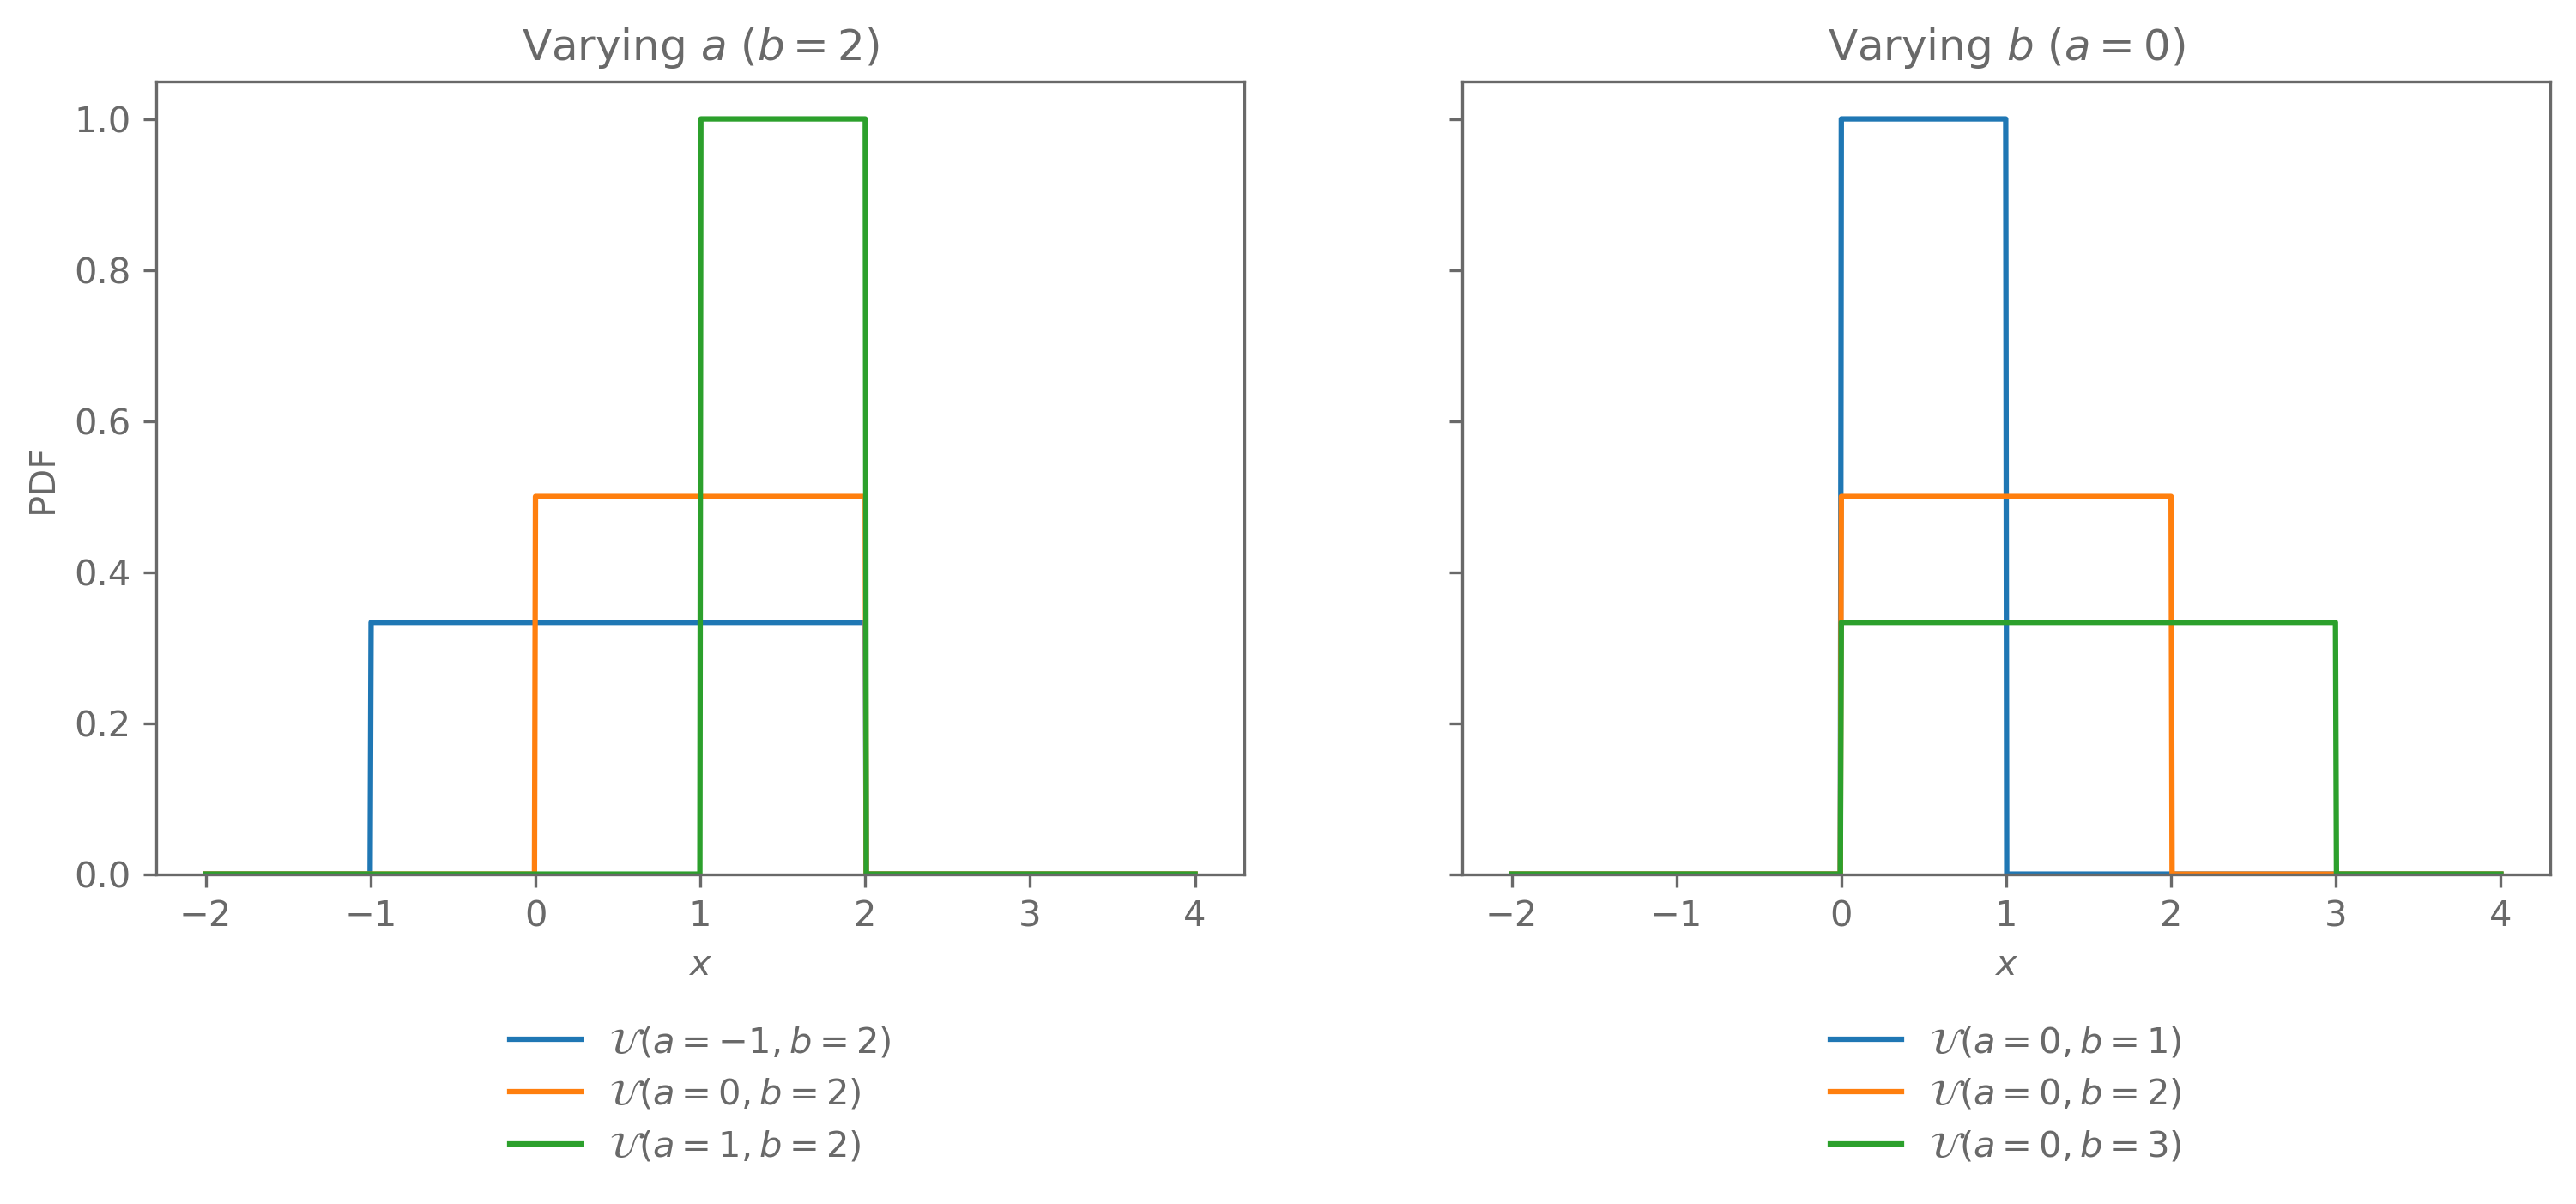

In [56]:
# Reference: a = 0, b = 2. Each panel varies one parameter and keeps the other fixed.
x = np.linspace(-2, 4, 1000)
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

b = 2
for a in [-1, 0, 1]:
    distr = scipy.stats.uniform(loc=a, scale=b - a)  # scipy uses loc = a, scale = b - a
    ax_a.plot(x, distr.pdf(x), label=rf"$\mathcal{{U}}(a={a}, b={b})$")
ax_a.set_title(f"Varying $a$ ($b={b}$)")

a = 0
for b in [1, 2, 3]:
    distr = scipy.stats.uniform(loc=a, scale=b - a)
    ax_b.plot(x, distr.pdf(x), label=rf"$\mathcal{{U}}(a={a}, b={b})$")
ax_b.set_title(f"Varying $b$ ($a={a}$)")

for ax in (ax_a, ax_b):
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    ax.set_xlabel("$x$")
ax_a.set_ylabel("PDF")

#### Binomial (discrete)

Parameters: probability of success $p$, number of trials $n$

Text(0, 0.5, 'PMF')

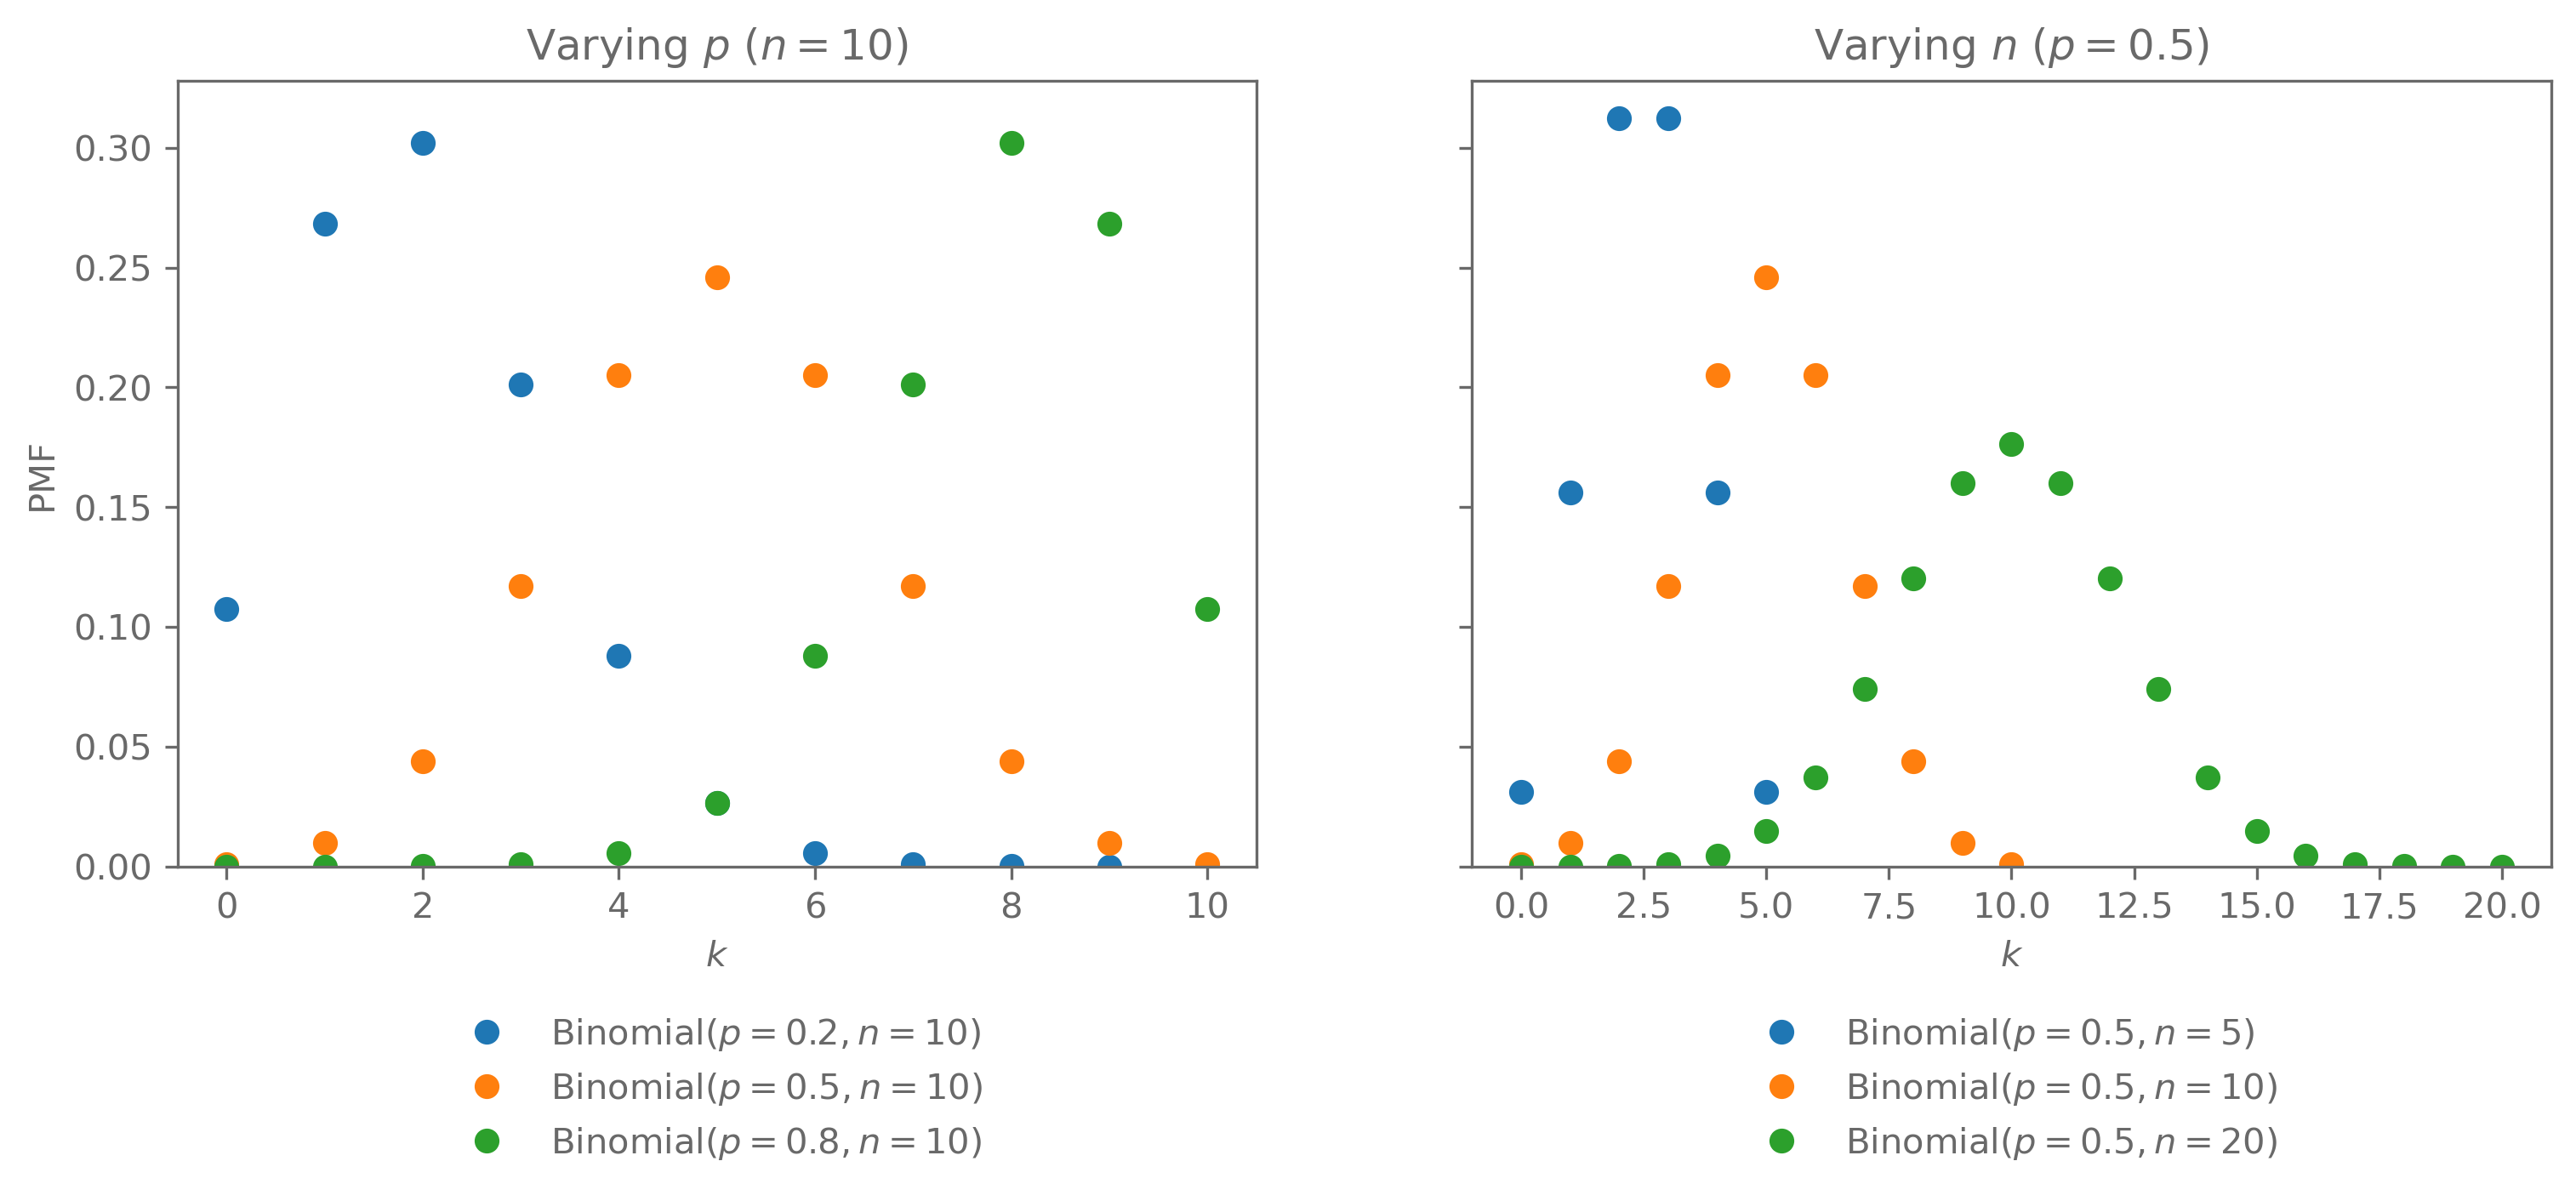

In [57]:
# Reference: p = 0.5, n = 10. Each panel varies one parameter and keeps the other fixed.
fig, (ax_p, ax_n) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

n = 10
for p in [0.2, 0.5, 0.8]:
    k = np.arange(n + 1)  # possible values k = 0, ..., n
    distr = scipy.stats.binom(p=p, n=n)
    ax_p.plot(k, distr.pmf(k), "o", label=rf"Binomial$(p={p}, n={n})$")
ax_p.set_title(f"Varying $p$ ($n={n}$)")

p = 0.5
for n in [5, 10, 20]:
    k = np.arange(n + 1)
    distr = scipy.stats.binom(p=p, n=n)
    ax_n.plot(k, distr.pmf(k), "o", label=rf"Binomial$(p={p}, n={n})$")
ax_n.set_title(f"Varying $n$ ($p={p}$)")

for ax in (ax_p, ax_n):
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    ax.set_xlabel("$k$")
ax_p.set_ylabel("PMF")

#### Multinomial (discrete)

Parameters: probabilities $p_1, \dots, p_k$ of the $k$ outcomes, number of trials $n$

We use $k = 3$ outcomes (e.g. a three-sided die). The counts $(x_1, x_2, x_3)$ always add up to $n$, so $x_3 = n - x_1 - x_2$ is fixed by the other two. Each possible outcome is therefore a point $(x_1, x_2)$, which we colour by its probability.

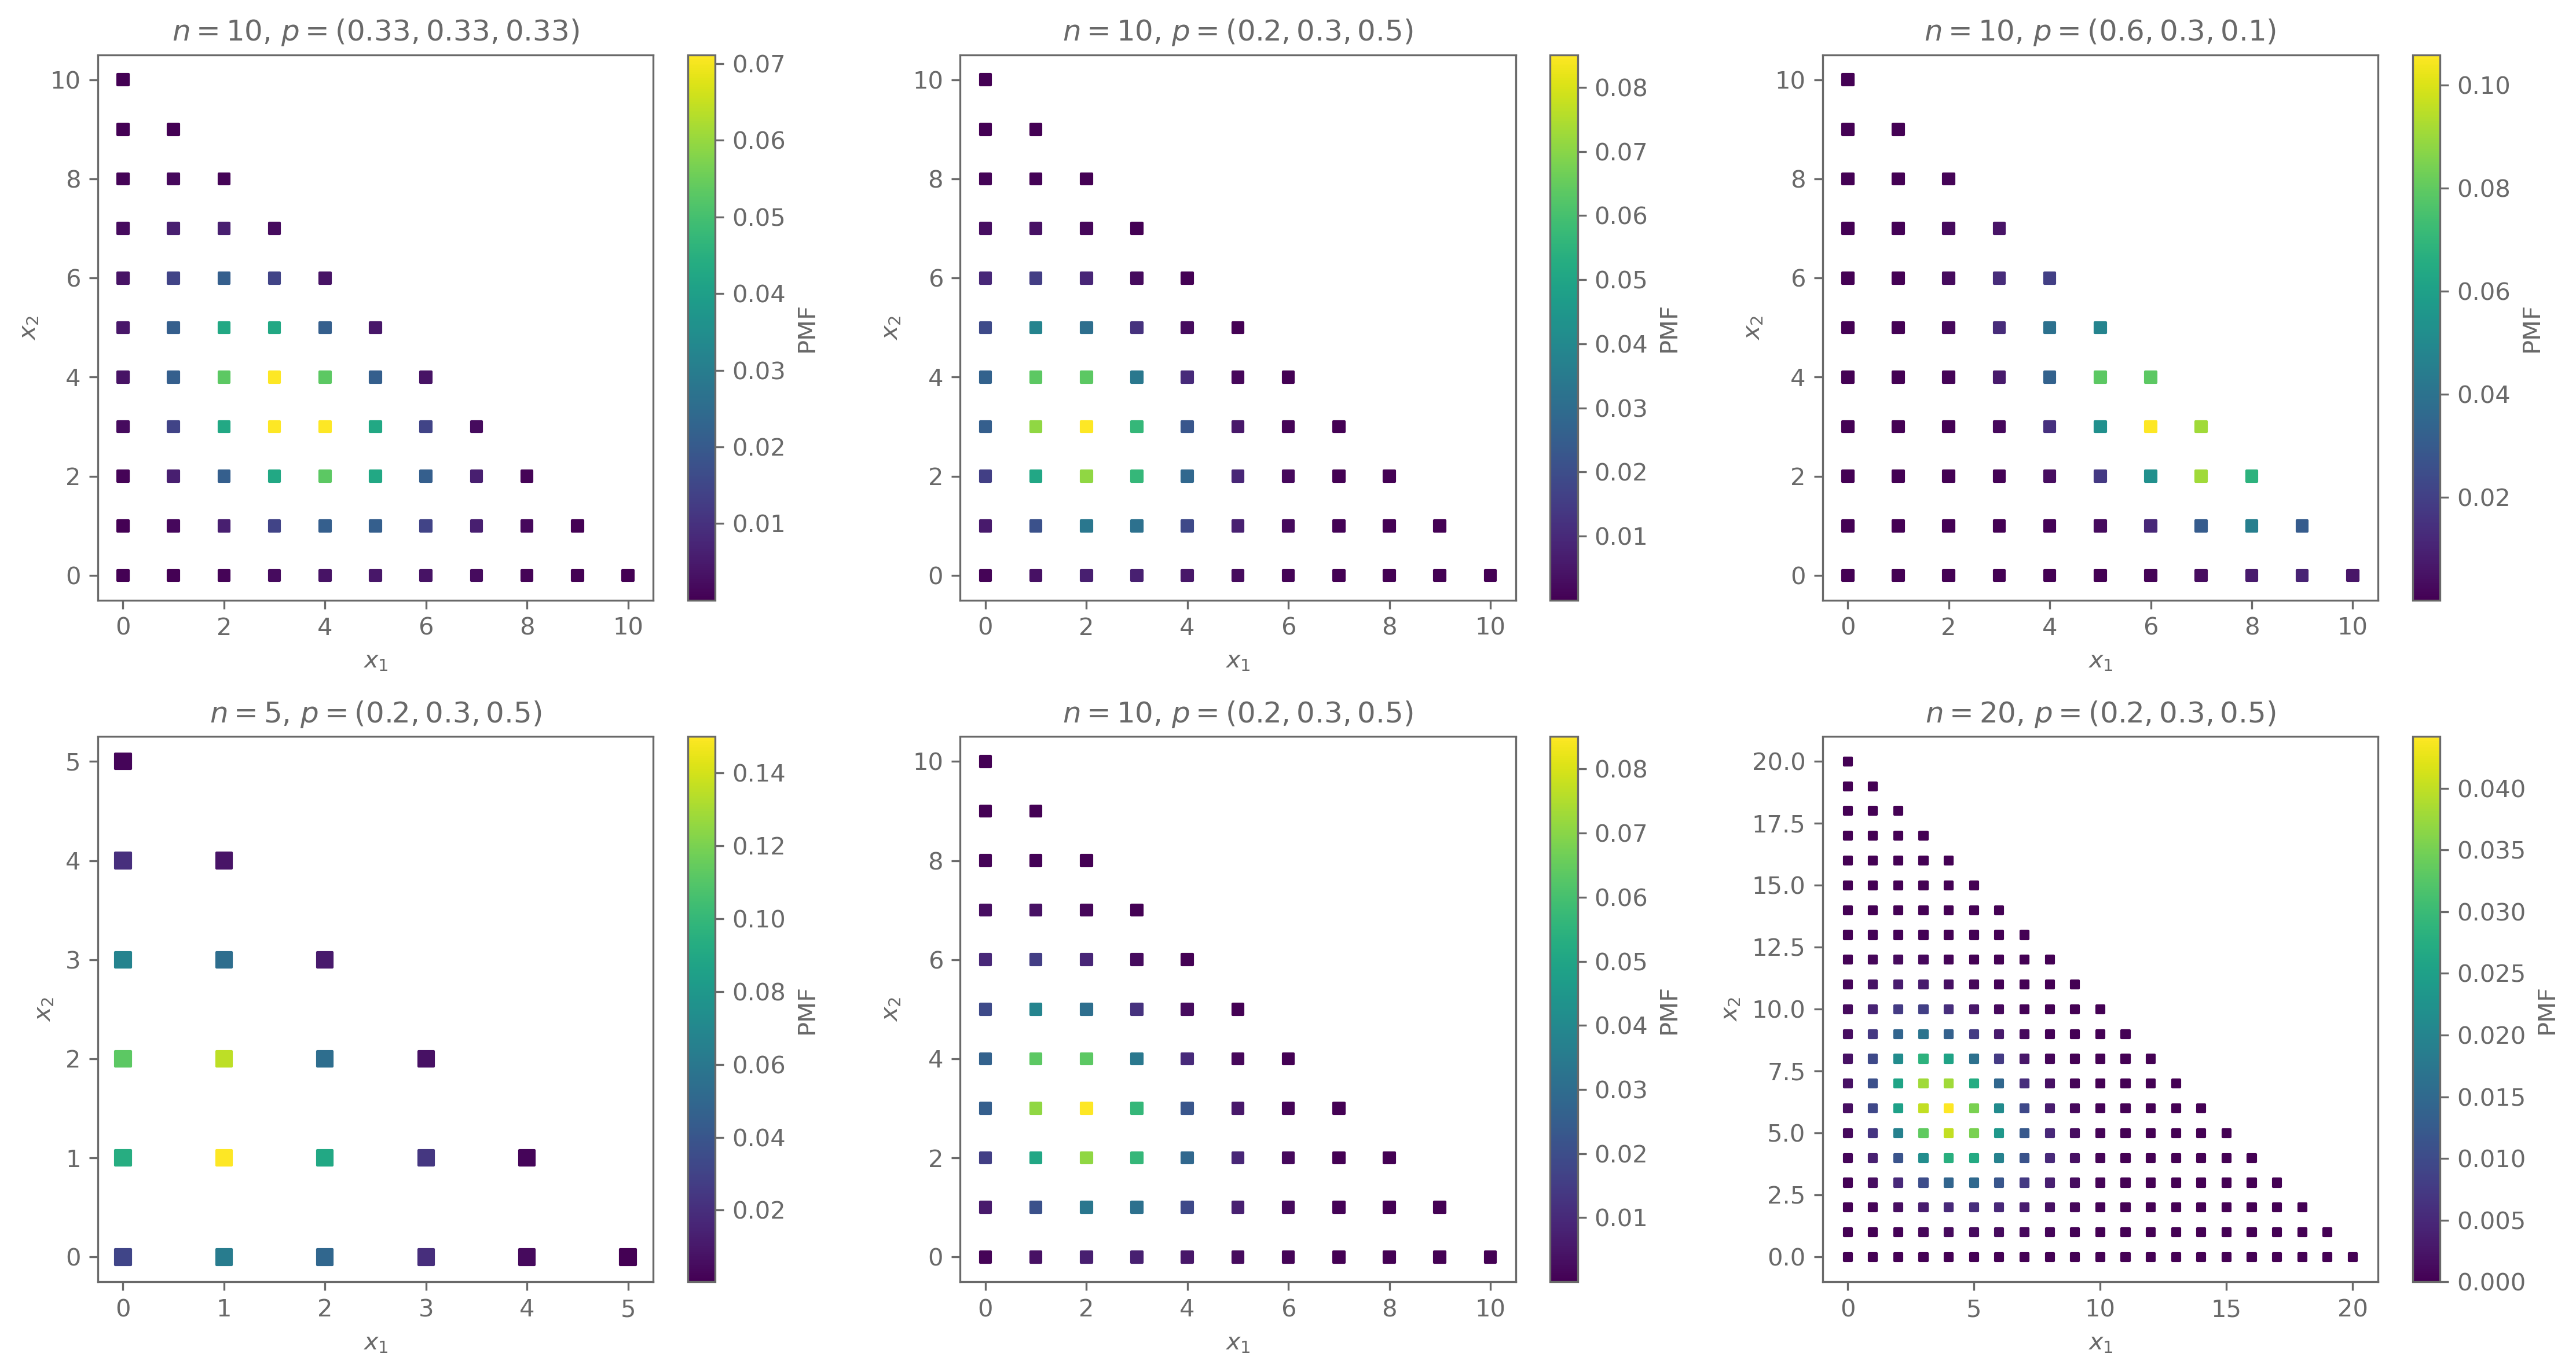

In [58]:
# Reference: n = 10, p = (0.2, 0.3, 0.5).
# Top row varies p (n fixed), bottom row varies n (p fixed).
def plot_multinomial(ax, n, p):
    distr = scipy.stats.multinomial(n=n, p=p)

    # All possible outcomes (x1, x2, x3) with x1 + x2 + x3 = n
    x1, x2 = [], []
    for a in range(n + 1):
        for b in range(n + 1 - a):
            x1.append(a)
            x2.append(b)
    x1, x2 = np.array(x1), np.array(x2)
    x3 = n - x1 - x2

    pmf = distr.pmf(np.stack([x1, x2, x3], axis=1))

    points = ax.scatter(x1, x2, c=pmf, s=200/n, marker="s")  # smaller squares for larger n
    plt.colorbar(points, ax=ax, label="PMF")
    ax.set_title(rf"$n={n}$, $p=({p[0]:.2g}, {p[1]:.2g}, {p[2]:.2g})$")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

n = 10
for ax, p in zip(axes[0], [[1/3, 1/3, 1/3], [0.2, 0.3, 0.5], [0.6, 0.3, 0.1]]):
    plot_multinomial(ax, n, p)

p = [0.2, 0.3, 0.5]
for ax, n in zip(axes[1], [5, 10, 20]):
    plot_multinomial(ax, n, p)

fig.tight_layout()

#### Poisson (discrete)

Parameter: event rate $\lambda$ (also the mean and the variance)

Text(0, 0.5, 'PMF')

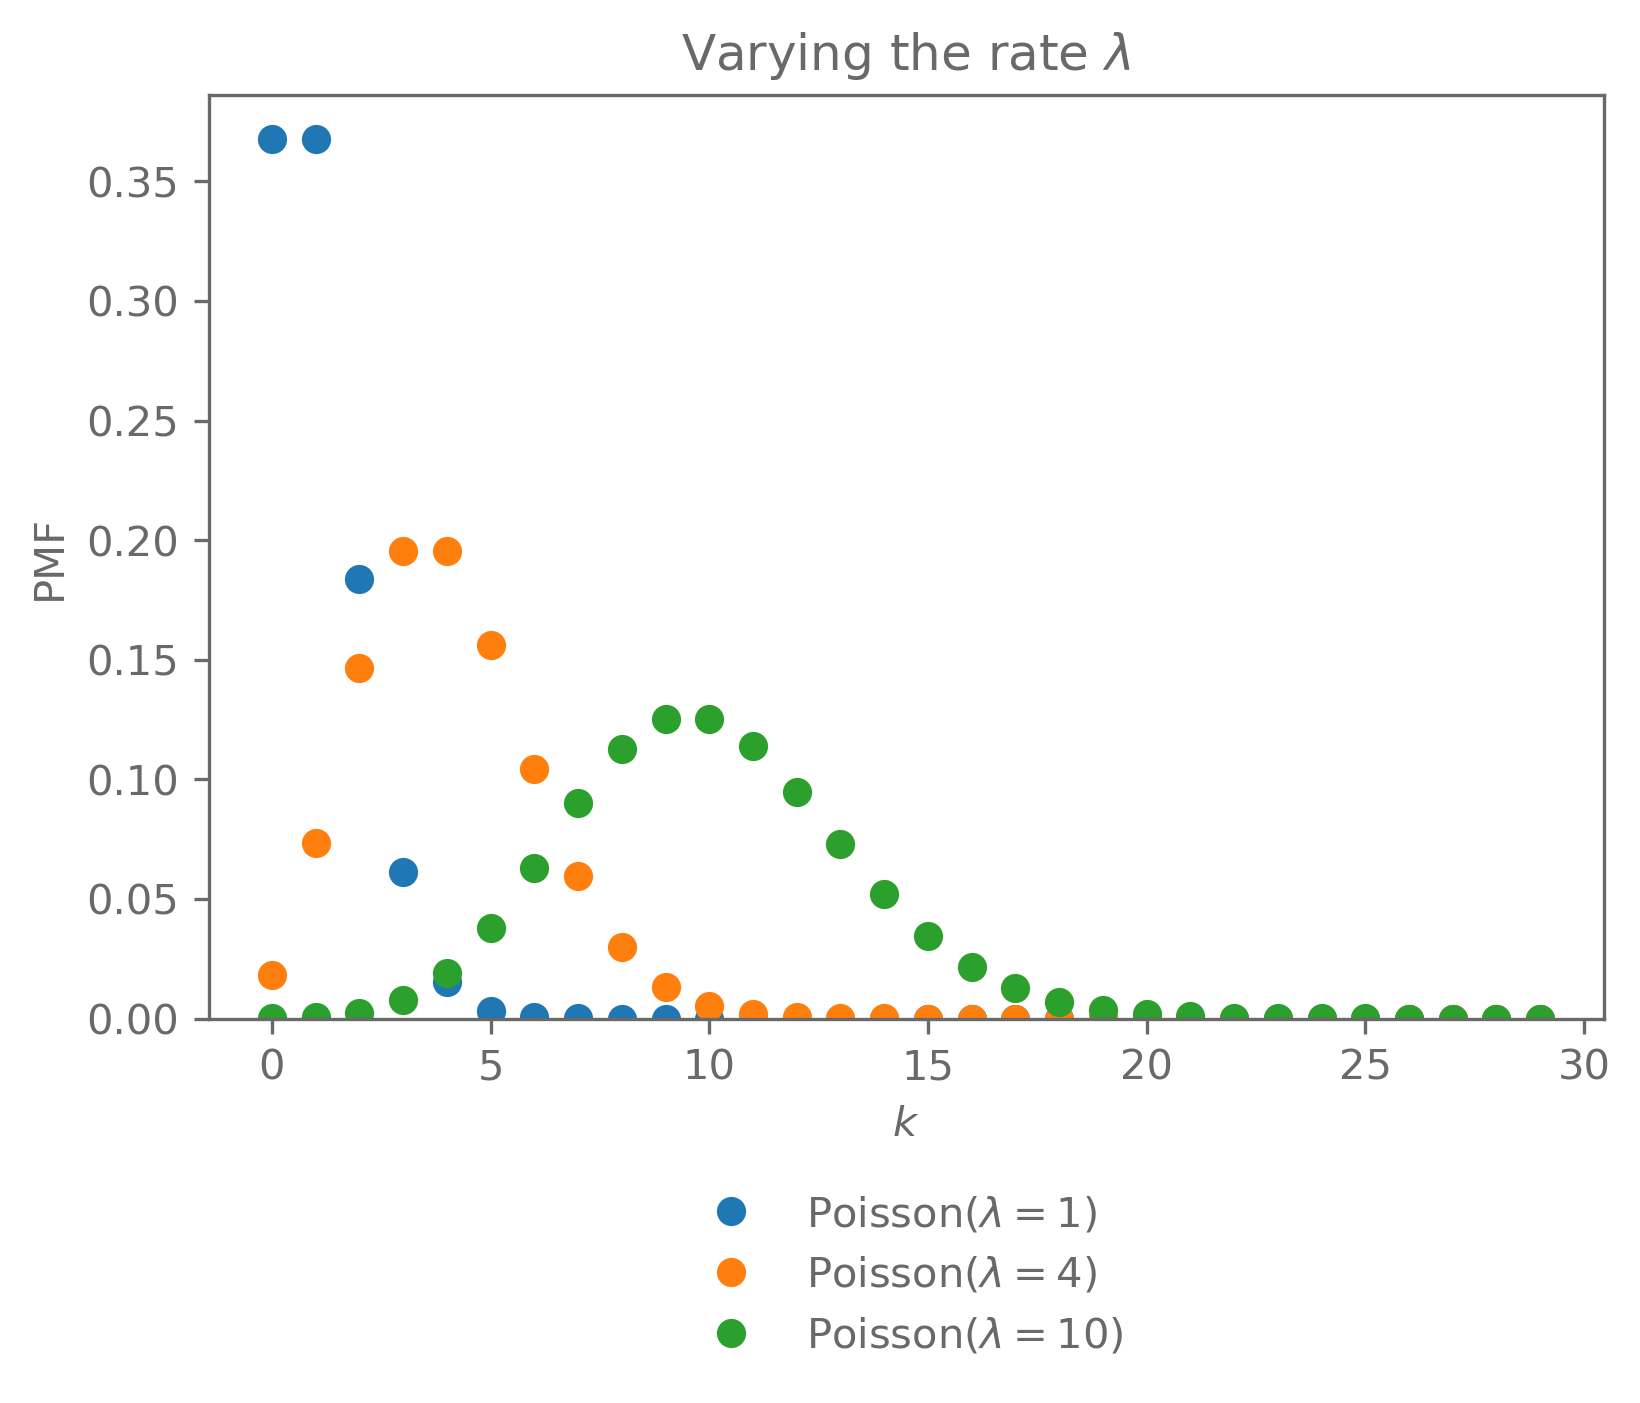

In [59]:
lambdas = [1, 4, 10]
k = np.arange(3 * max(lambdas)) 

fig, ax = plt.subplots(figsize=(6, 4))

for lam in lambdas:
    distr = scipy.stats.poisson(mu=lam)
    ax.plot(k, distr.pmf(k), "o", label=rf"Poisson$(\lambda={lam})$")
ax.set_title(r"Varying the rate $\lambda$")

ax.set_ylim(bottom=0)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax.set_xlabel("$k$")
ax.set_ylabel("PMF")

#### Normal $\Norm(\mu, \sigma^2)$ (continuous)

Parameters: mean $\mu$, variance $\sigma^2$

Text(0, 0.5, 'PDF')

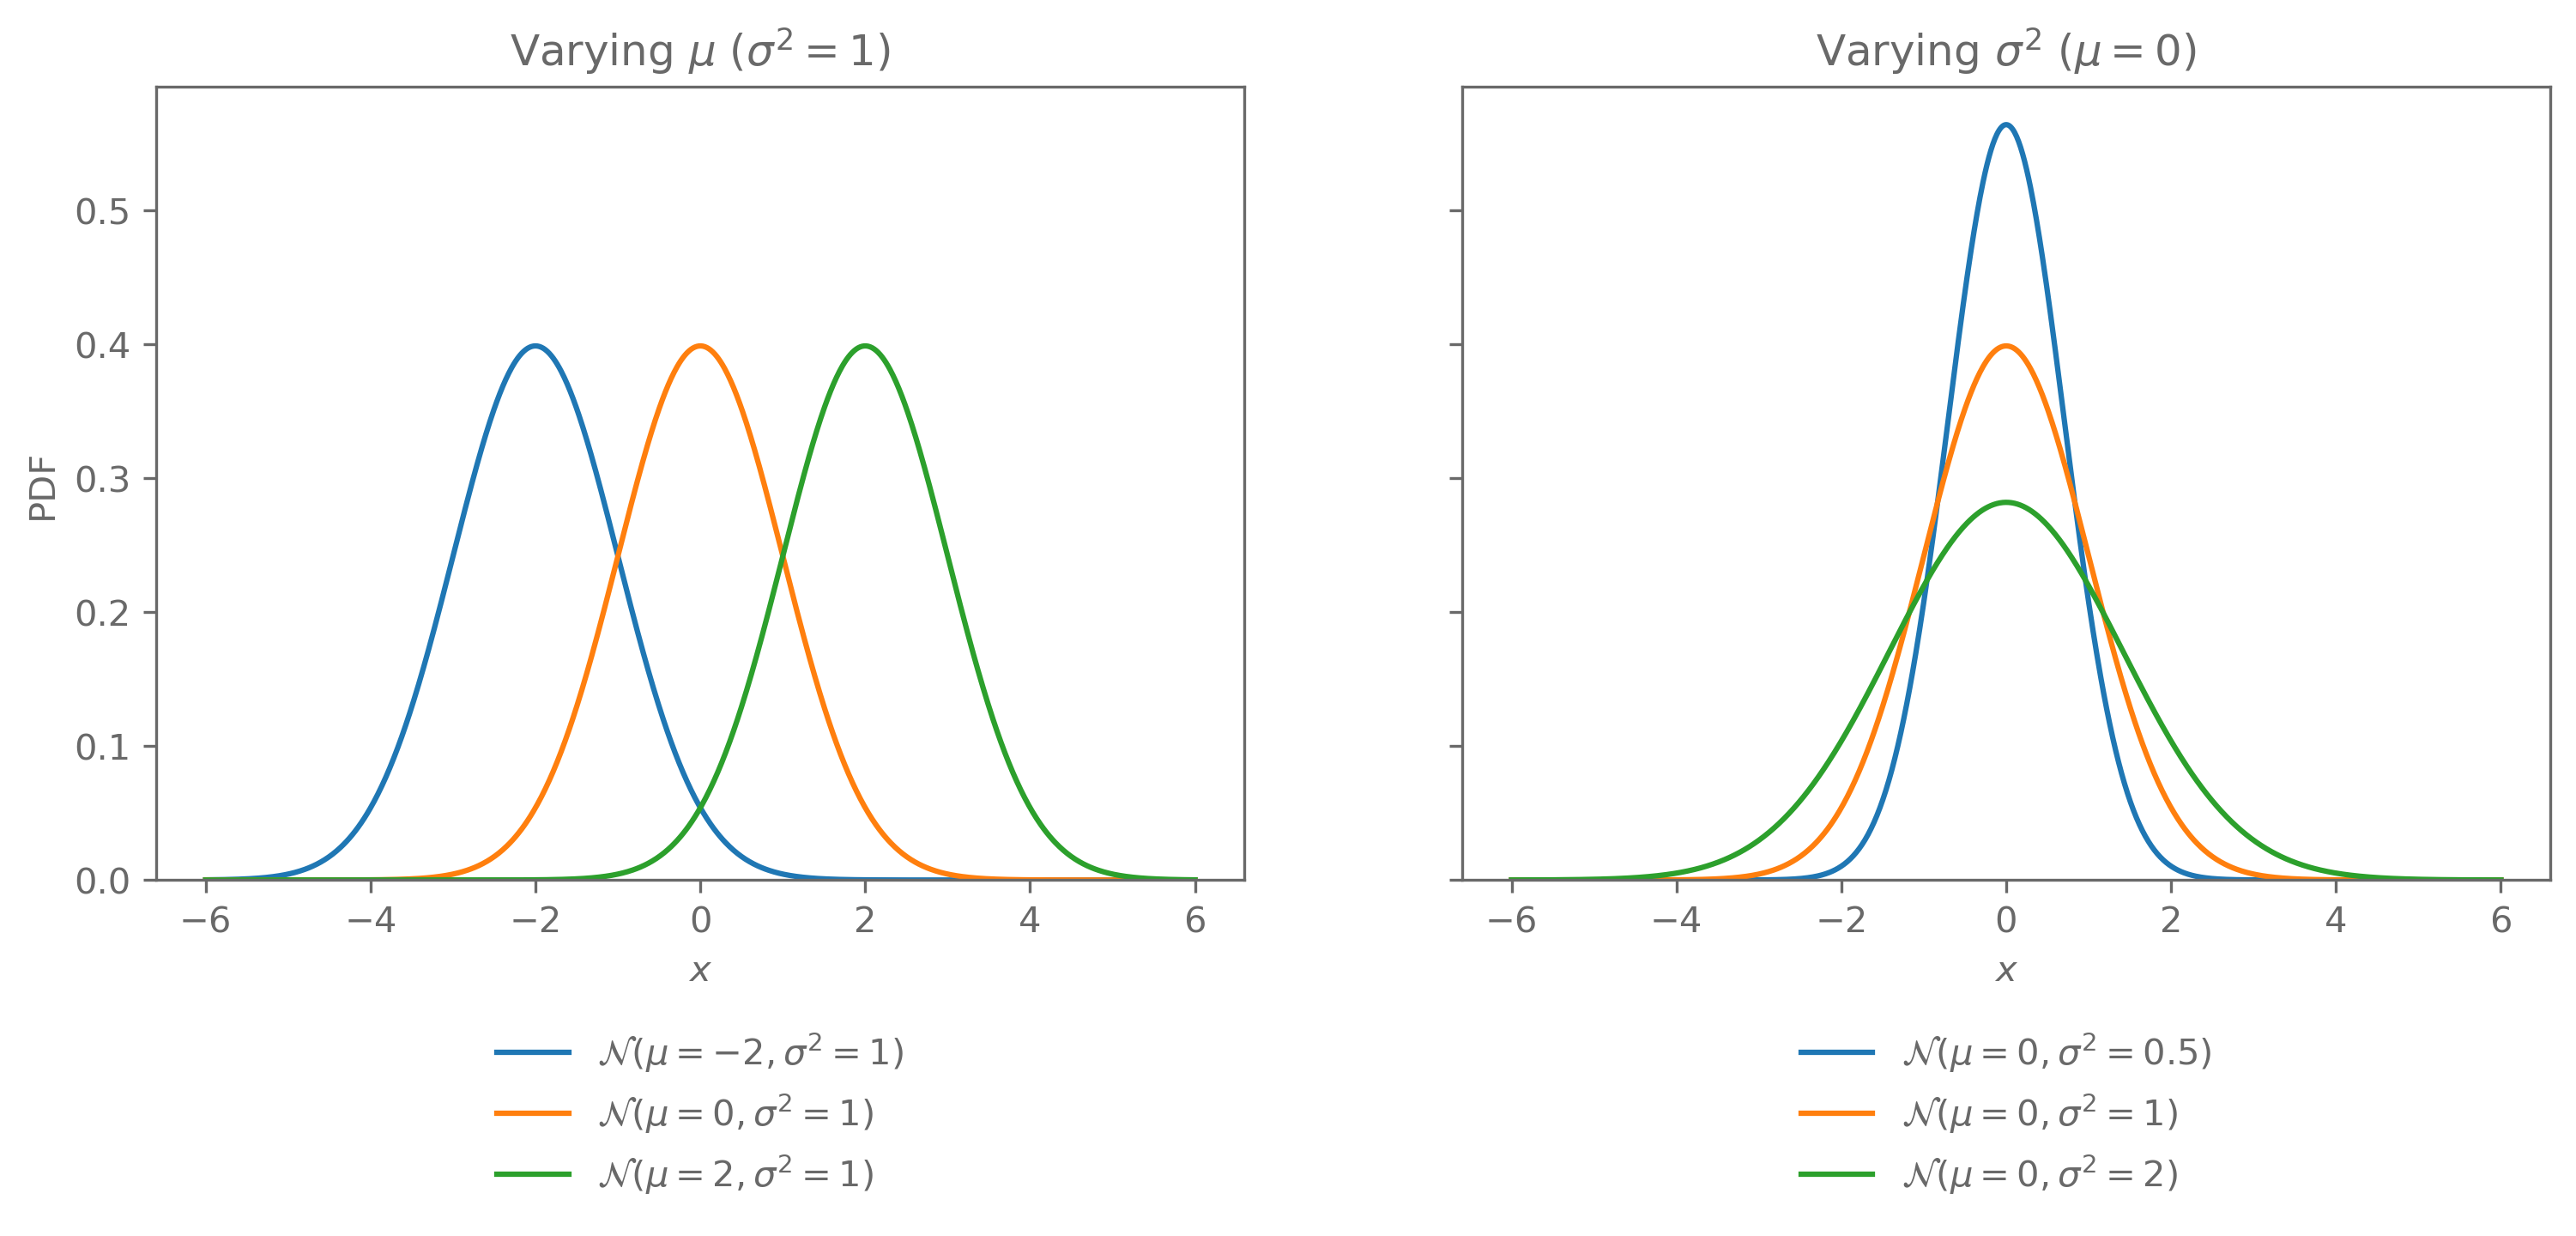

In [60]:
# Reference: mu = 0, sigma^2 = 1. Each panel varies one parameter and keeps the other fixed.
x = np.linspace(-6, 6, 1000)
fig, (ax_mu, ax_var) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

var = 1
for mu in [-2, 0, 2]:
    distr = scipy.stats.norm(loc=mu, scale=np.sqrt(var))  # scipy uses the standard deviation, not the variance
    ax_mu.plot(x, distr.pdf(x), label=rf"$\mathcal{{N}}(\mu={mu}, \sigma^2={var})$")
ax_mu.set_title(rf"Varying $\mu$ ($\sigma^2={var}$)")

mu = 0
for var in [0.5, 1, 2]:
    distr = scipy.stats.norm(loc=mu, scale=np.sqrt(var))
    ax_var.plot(x, distr.pdf(x), label=rf"$\mathcal{{N}}(\mu={mu}, \sigma^2={var})$")
ax_var.set_title(rf"Varying $\sigma^2$ ($\mu={mu}$)")

for ax in (ax_mu, ax_var):
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    ax.set_xlabel("$x$")
ax_mu.set_ylabel("PDF")

#### Multivariate normal $\Norm(\vec\mu, \Sigma)$ (continuous)

Parameters: mean $\vec\mu$, covariance $\Sigma$

We use 2 dimensions, $\vec x = (x_1, x_2)$, and draw contours of the PDF. The covariance is $\Sigma = \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}$ with correlation $\rho$. The top row varies $\vec\mu$, the bottom row varies $\Sigma$ (through $\rho$).

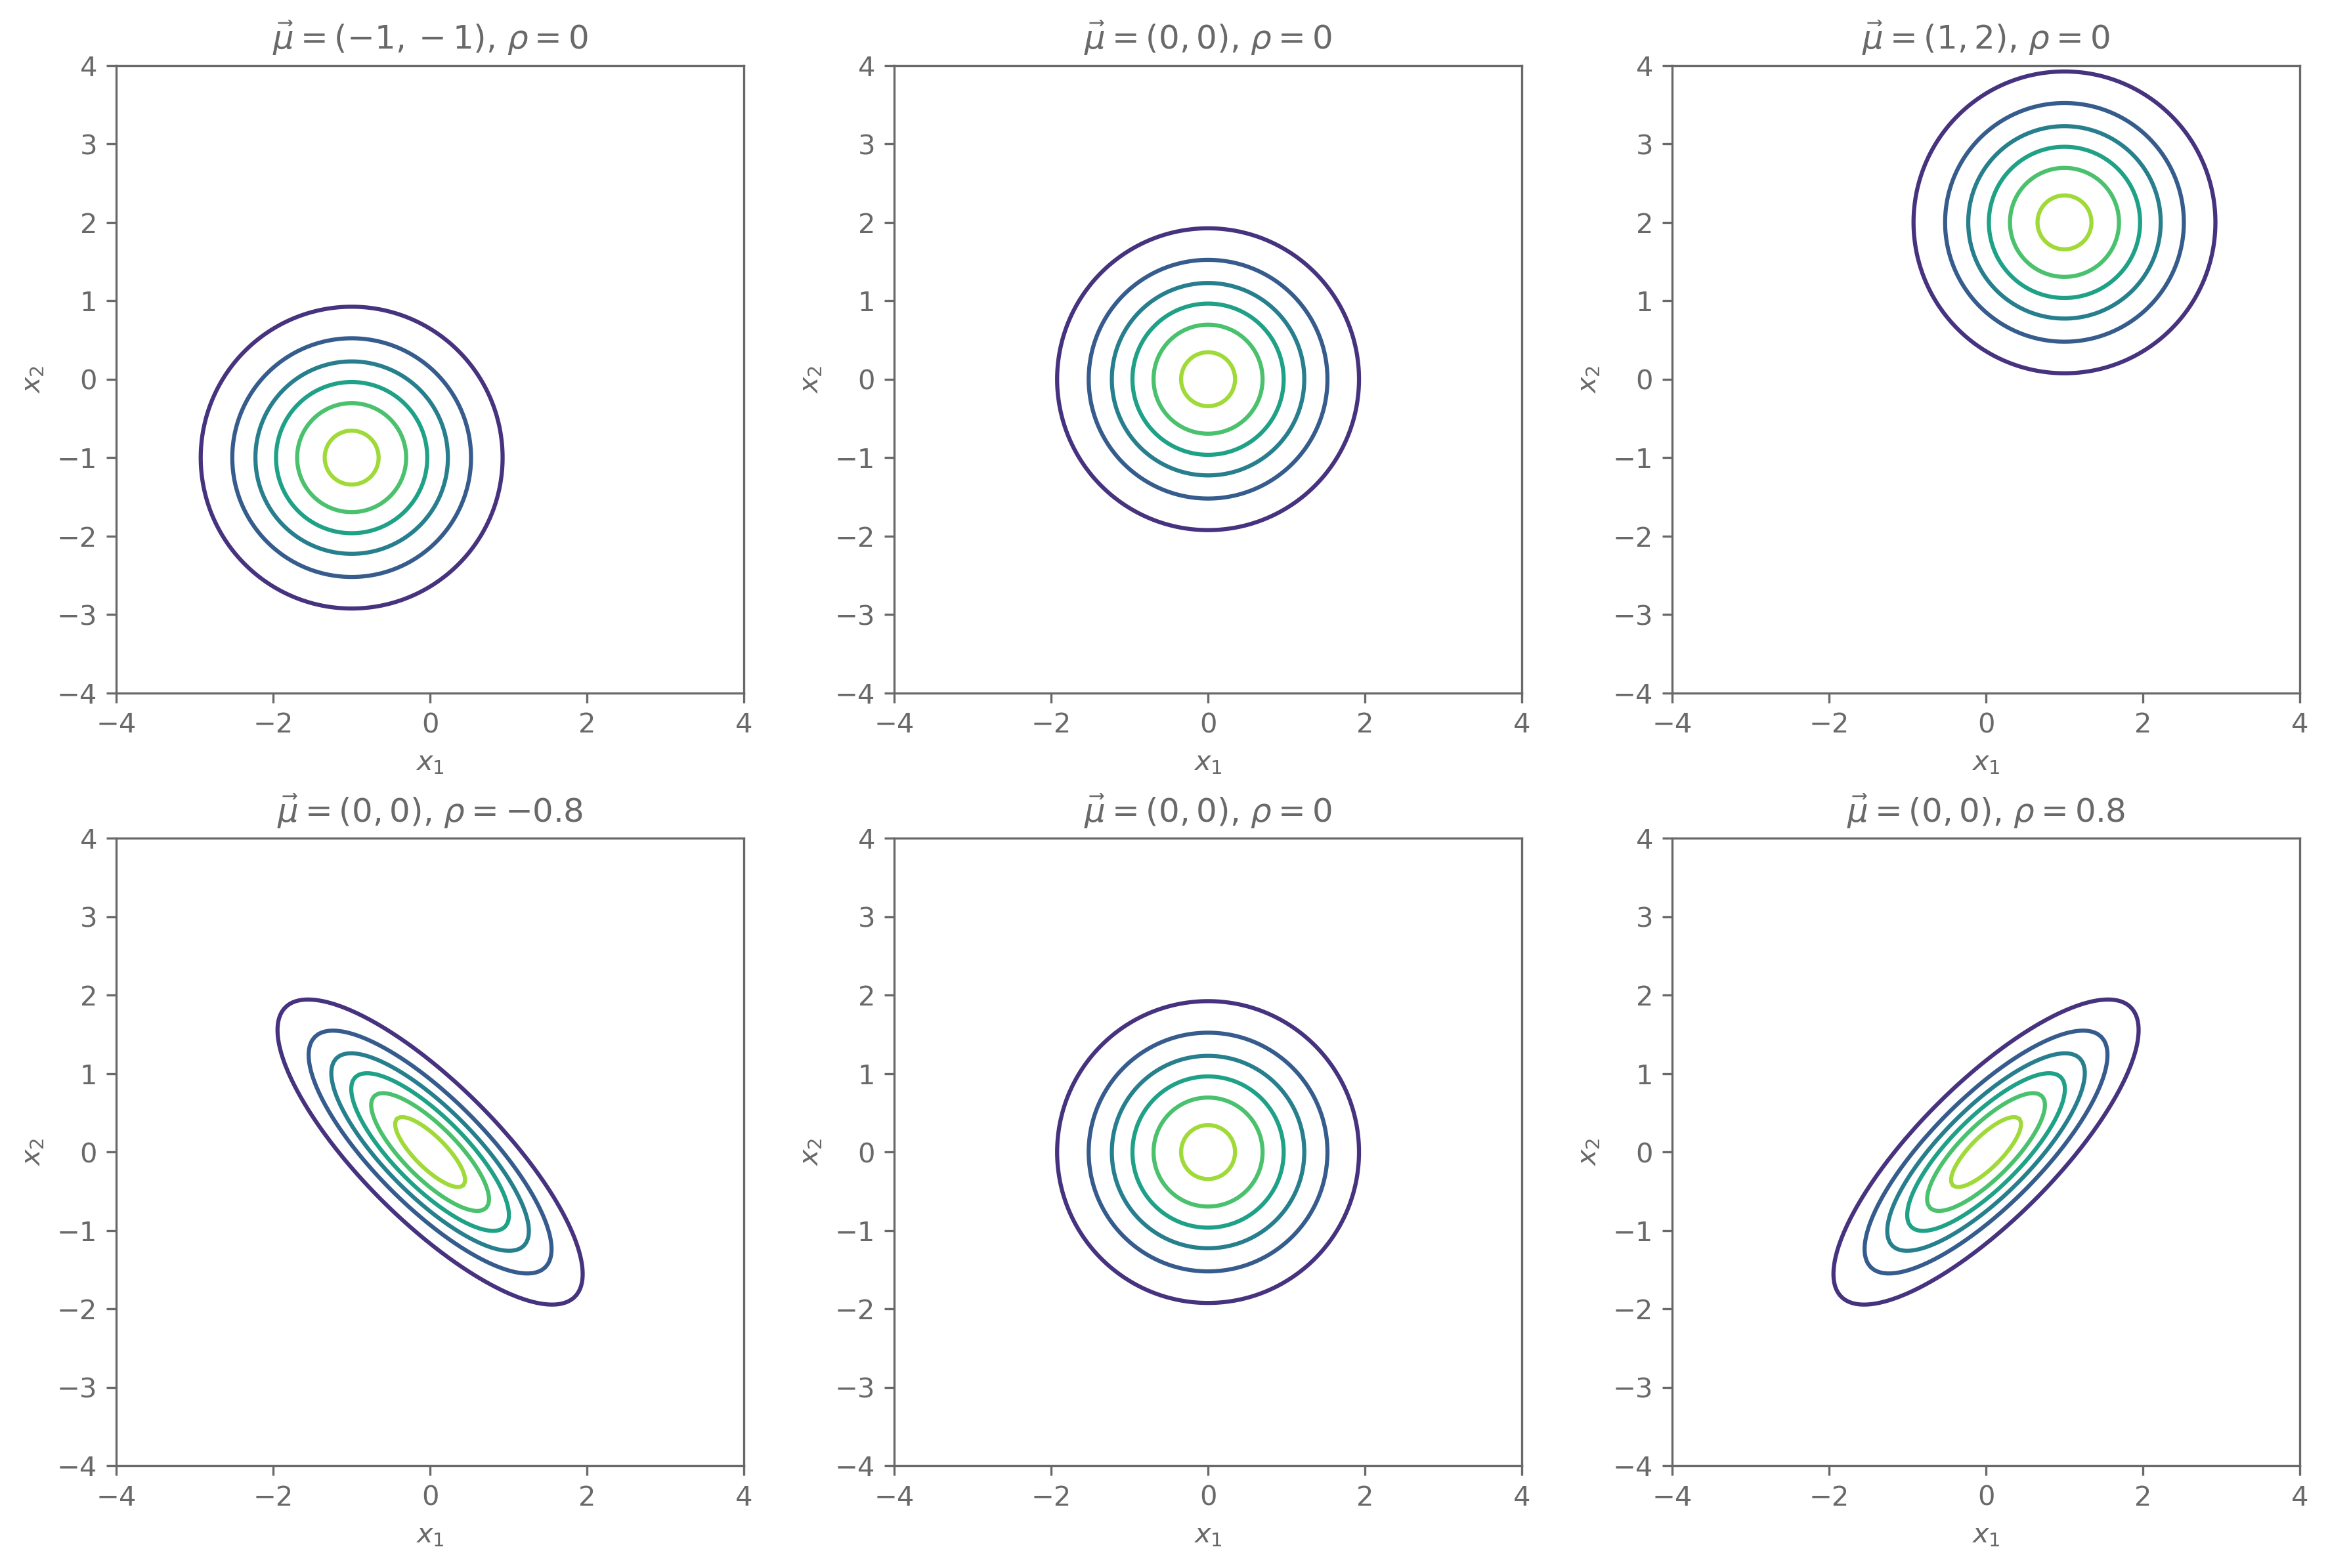

In [61]:
# Reference: mu = (0, 0), rho = 0. Top row varies mu (rho fixed), bottom row varies Sigma via rho (mu fixed).
x1, x2 = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-4, 4, 200))
points = np.stack([x1, x2], axis=-1)

def plot_mvn(ax, mu, rho):
    cov = [[1, rho], [rho, 1]]
    distr = scipy.stats.multivariate_normal(mean=mu, cov=cov)
    ax.contour(x1, x2, distr.pdf(points), levels=6)
    ax.set_title(rf"$\vec\mu=({mu[0]}, {mu[1]})$, $\rho={rho}$")
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

rho = 0
for ax, mu in zip(axes[0], [(-1, -1), (0, 0), (1, 2)]):
    plot_mvn(ax, mu, rho)

mu = (0, 0)
for ax, rho in zip(axes[1], [-0.8, 0, 0.8]):
    plot_mvn(ax, mu, rho)

fig.tight_layout()

#### Chi-squared $\chi^2_\nu$ (continuous)

Parameter: number of degrees of freedom $\nu$

Text(0, 0.5, 'PDF')

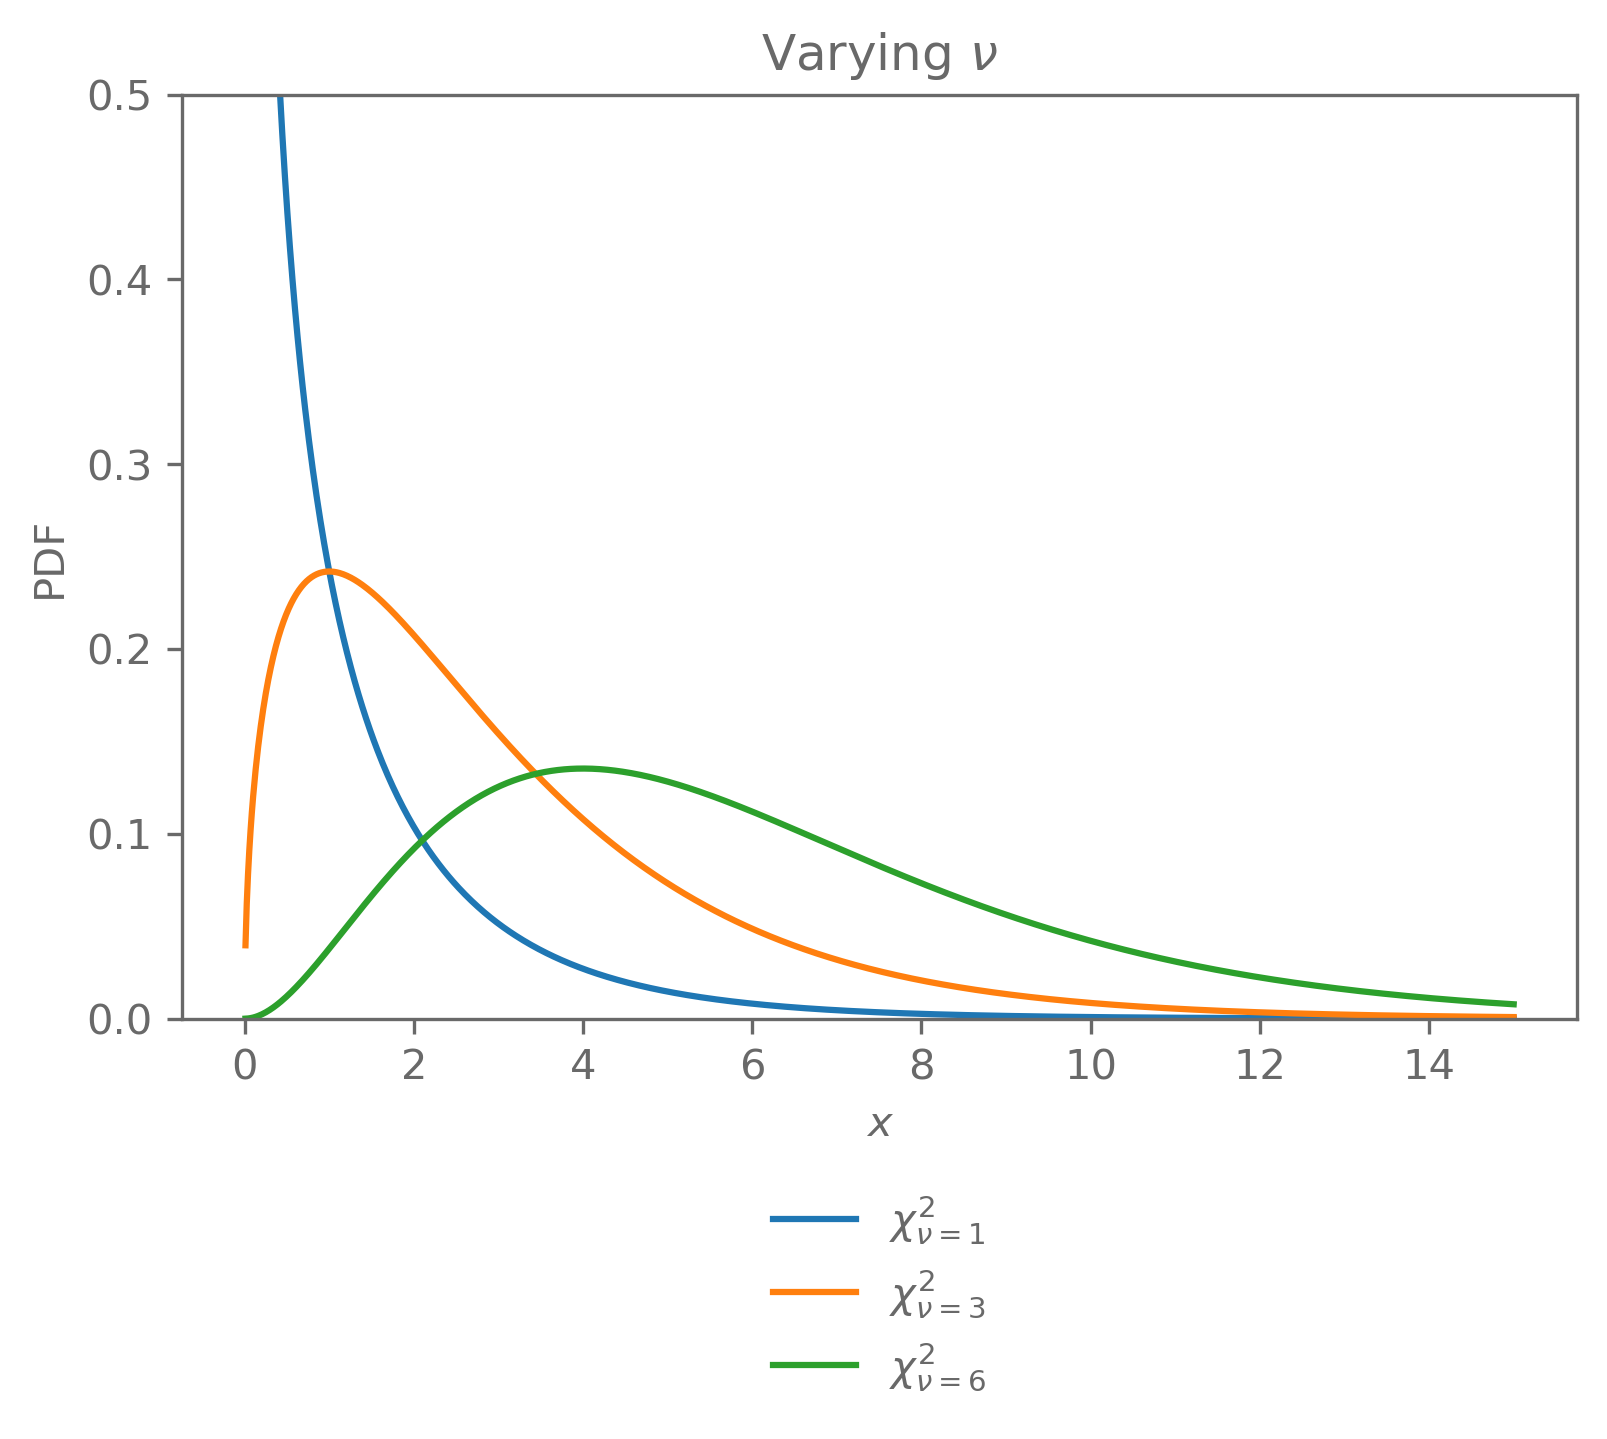

In [62]:
# One parameter, so one panel
x = np.linspace(0.01, 15, 1000)  # the PDF is 0 for x < 0 (and diverges at x = 0 for nu = 1)
fig, ax = plt.subplots(figsize=(6, 4))

for nu in [1, 3, 6]:
    distr = scipy.stats.chi2(df=nu)
    ax.plot(x, distr.pdf(x), label=rf"$\chi^2_{{\nu={nu}}}$")
ax.set_title(r"Varying $\nu$")

ax.set_ylim(0, 0.5)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax.set_xlabel("$x$")
ax.set_ylabel("PDF")

#### Cauchy (continuous)

Parameters: location $x_0$, scale $\gamma$

Text(0, 0.5, 'PDF')

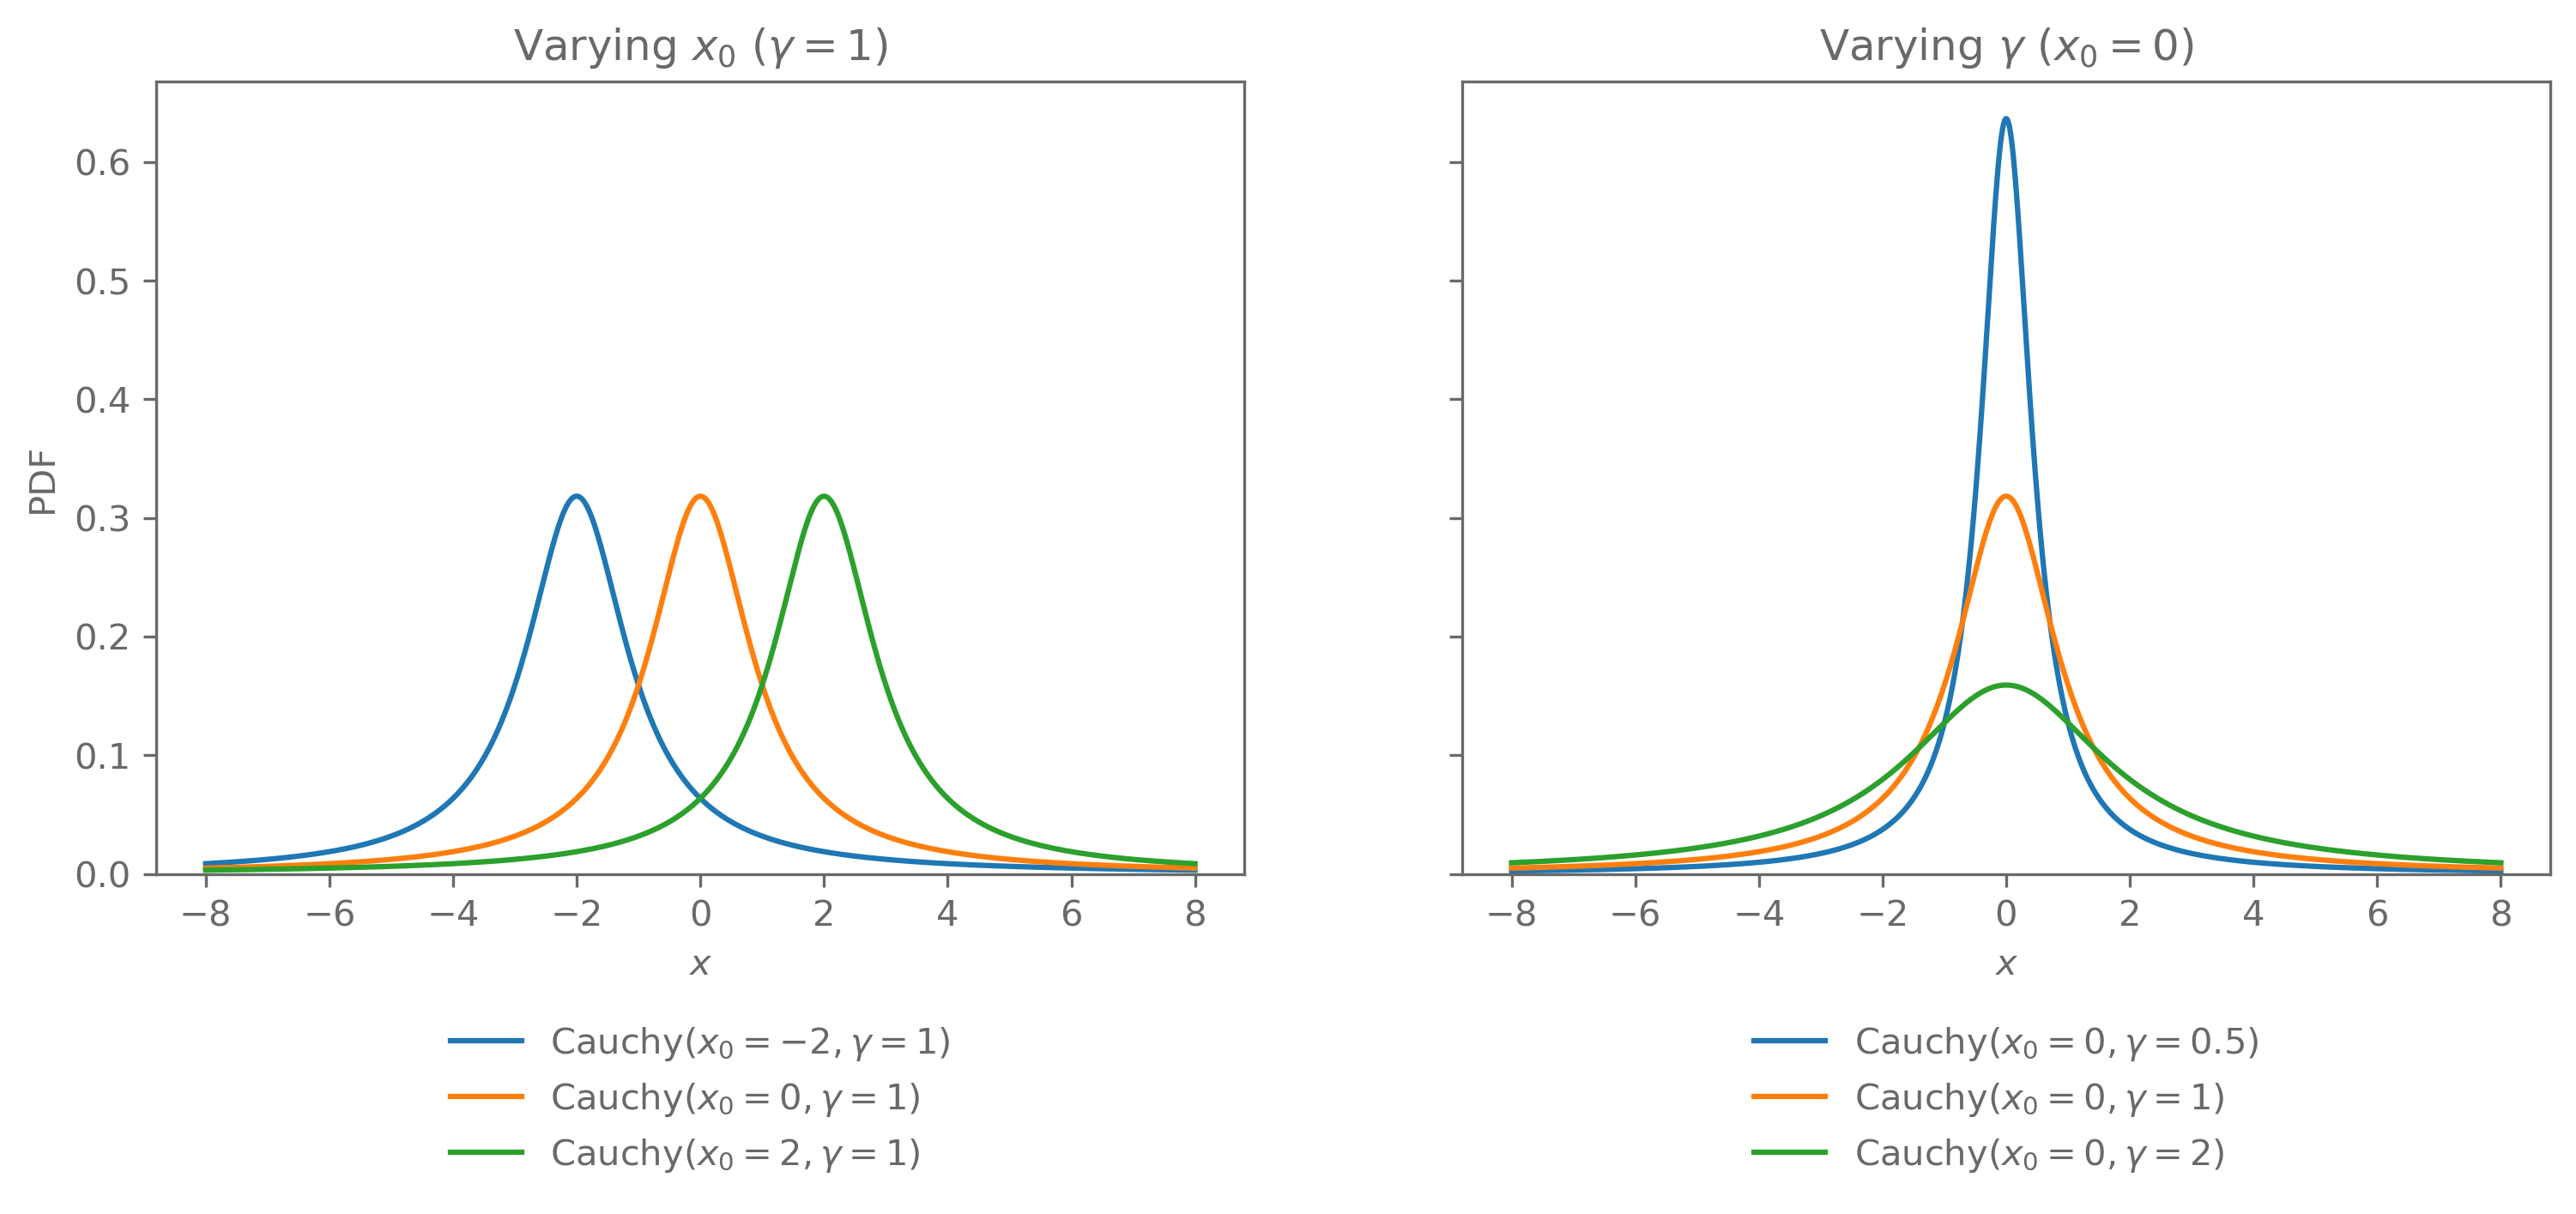

In [63]:
# Reference: x0 = 0, gamma = 1. Each panel varies one parameter and keeps the other fixed.
x = np.linspace(-8, 8, 1000)
fig, (ax_x0, ax_gamma) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

gamma = 1
for x0 in [-2, 0, 2]:
    distr = scipy.stats.cauchy(loc=x0, scale=gamma)
    ax_x0.plot(x, distr.pdf(x), label=rf"Cauchy$(x_0={x0}, \gamma={gamma})$")
ax_x0.set_title(rf"Varying $x_0$ ($\gamma={gamma}$)")

x0 = 0
for gamma in [0.5, 1, 2]:
    distr = scipy.stats.cauchy(loc=x0, scale=gamma)
    ax_gamma.plot(x, distr.pdf(x), label=rf"Cauchy$(x_0={x0}, \gamma={gamma})$")
ax_gamma.set_title(rf"Varying $\gamma$ ($x_0={x0}$)")

for ax in (ax_x0, ax_gamma):
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    ax.set_xlabel("$x$")
ax_x0.set_ylabel("PDF")

#### Power law (continuous)

Parameters: lower limit $a$, upper limit $b$, exponent $\alpha$ (with $\alpha \neq 1$)

scipy has no power law with both limits in this form, so we code the PDF from the lecture ourselves. Power laws are straight lines on log-log axes, so we use those. The PDF is 0 outside $[a, b]$, which cannot be shown on a log axis, so each curve is drawn on its support only.

Text(0, 0.5, 'PDF')

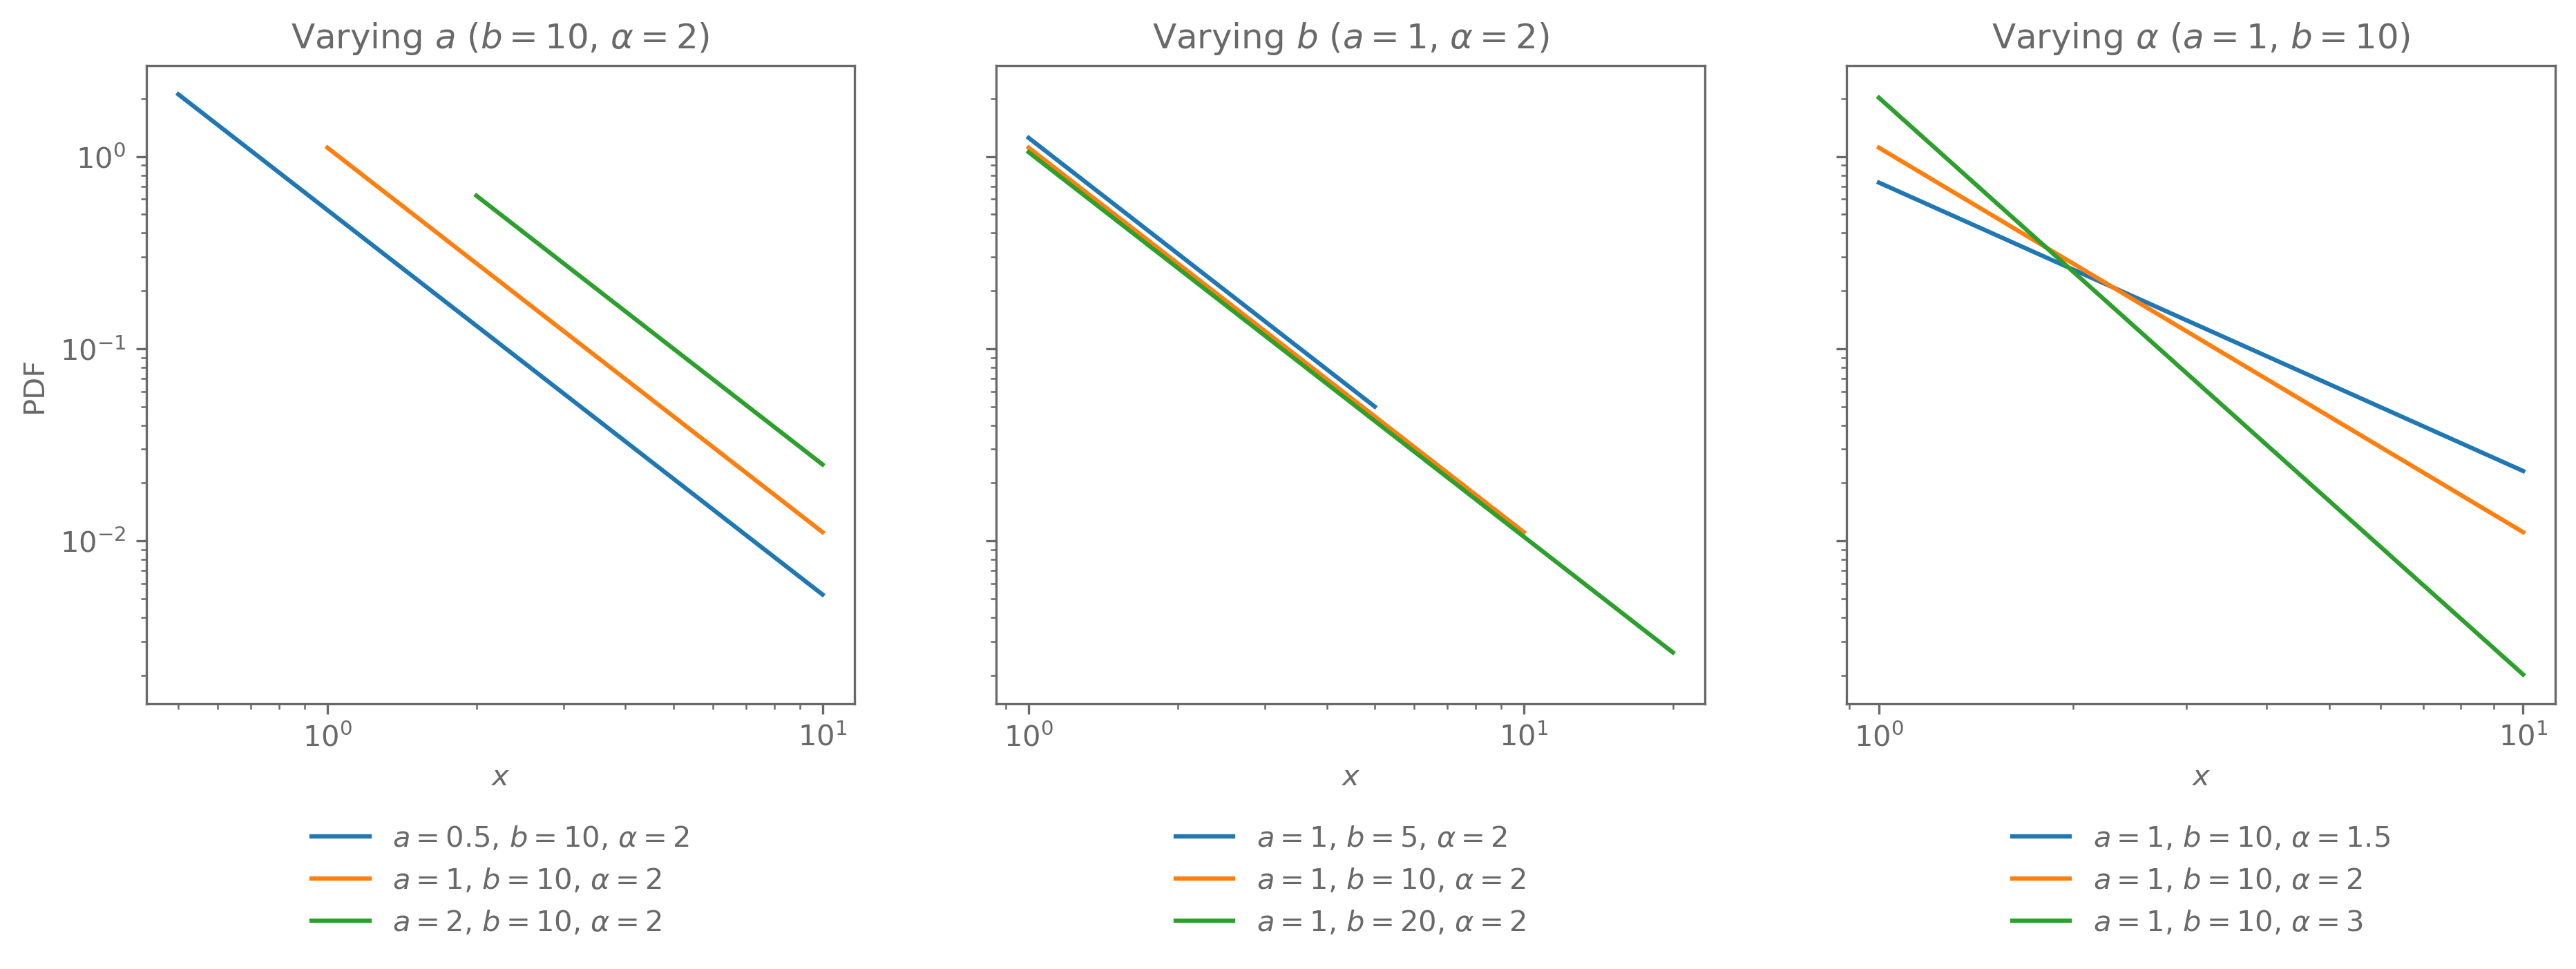

In [64]:
# Reference: a = 1, b = 10, alpha = 2. Three parameters, so three panels.
def power_law_pdf(x, a, b, alpha):
    x = np.asarray(x, dtype=float)
    norm = (1 - alpha) / (b**(1 - alpha) - a**(1 - alpha))
    return np.where((a <= x) & (x <= b), norm * x**(-alpha), 0.0)

fig, (ax_a, ax_b, ax_alpha) = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

def plot_power_law(ax, a, b, alpha):
    x = np.geomspace(a, b, 200)  # support only
    ax.plot(x, power_law_pdf(x, a, b, alpha), label=rf"$a={a}$, $b={b}$, $\alpha={alpha}$")

b, alpha = 10, 2
for a in [0.5, 1, 2]:
    plot_power_law(ax_a, a, b, alpha)
ax_a.set_title(rf"Varying $a$ ($b={b}$, $\alpha={alpha}$)")

a, alpha = 1, 2
for b in [5, 10, 20]:
    plot_power_law(ax_b, a, b, alpha)
ax_b.set_title(rf"Varying $b$ ($a={a}$, $\alpha={alpha}$)")

a, b = 1, 10
for alpha in [1.5, 2, 3]:
    plot_power_law(ax_alpha, a, b, alpha)
ax_alpha.set_title(rf"Varying $\alpha$ ($a={a}$, $b={b}$)")

for ax in (ax_a, ax_b, ax_alpha):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15))
    ax.set_xlabel("$x$")
ax_a.set_ylabel("PDF")

### 4.2 Sum of two independent Gaussian RVs

Let $X\sim\Norm(\mu_X, \sigma_X^2)$ and $Y\sim\Norm(\mu_Y, \sigma_Y^2)$ be independent, and $Z = X+Y$.

Two facts do most of the work:
- Sums of Gaussian RVs are Gaussian (lecture, properties of the normal distribution). For independent RVs this also follows from the convolution formula in 4.3.
- A Gaussian is completely determined by its mean and variance, since its PDF depends only on $\mu$ and $\sigma^2$.

So $Z$ is Gaussian, and we only need $\E[Z]$ and $\Var[Z]$. Independence means that the joint PDF factorises, $p_{XY}(x, y) = p_X(x)\,p_Y(y)$.

**Mean.** By the definition of the expectation,
$$
    \E[Z] = \iint (x + y)\, p_X(x)\,p_Y(y) \dd x \dd y
          = \int x\, p_X(x) \dd x \int p_Y(y) \dd y + \int p_X(x) \dd x \int y\, p_Y(y) \dd y
          = \mu_X + \mu_Y \ ,
$$
using that each PDF integrates to 1.

**Variance.** Writing $Z - \E[Z] = (X - \mu_X) + (Y - \mu_Y)$ and expanding the square,
$$
    \Var[Z] = \E[(X - \mu_X)^2] + \E[(Y - \mu_Y)^2] + 2\,\E[(X - \mu_X)(Y - \mu_Y)] \ .
$$
The first two terms are $\sigma_X^2$ and $\sigma_Y^2$. The cross term vanishes because the joint PDF factorises:
$$
    \E[(X - \mu_X)(Y - \mu_Y)] = \int (x - \mu_X)\, p_X(x) \dd x \int (y - \mu_Y)\, p_Y(y) \dd y = 0 \cdot 0 = 0 \ .
$$
So $\Var[Z] = \sigma_X^2 + \sigma_Y^2$: for independent RVs, variances add.

Put together,
$$
    Z \sim \Norm(\mu_X + \mu_Y,\ \sigma_X^2 + \sigma_Y^2) \ .
$$

### 4.3 Sum of two independent RVs

Let $X\sim p_X$ and $Y\sim p_Y$. What is the distribution of $Z=X+Y$?

One way to solve this is to write the distribution of $Z$ as the marginal of the joint distribution $p_{XZ}$ of $X$ and $Z$:
$$
    p_Z(z) = \int p_{XZ}(x, z)\dd x \ .
$$

We find $p_{XZ}$ using a change of variables: $(x, y) = h\left((x, z)\right)$ with $y = z - x$,
$$
    p_{XZ}(x, z) = p_{XY}\left(h\left((x, z)\right)\right)|J_h| \ .
$$
The Jacobian of $h$ is $J_h = \begin{pmatrix} 1 & 0 \\ -1 & 1 \end{pmatrix}$, with determinant $|J_h| = 1$, so
$$
    p_{XZ}(x, z) = p_{XY}(x, z - x) = p_{X}(x)\,p_{Y}(z - x) \ ,
$$
where we used that $X$ and $Y$ are independent.
Put together we get
$$
    p_Z(z) = \int p_X(x)p_Y(z-x)\dd x\ .
$$
The distribution of the sum of two independent RVs is a convolution of their respective distributions.

### 4.4 PDF of the $\chi^2_{\nu=1}$ distribution

Let $X\sim\Norm(0, 1)$ and $Z = g(X) = X^2$. The function $g(x) = x^2$ is not monotonic, so we use the change-of-variables formula for non-monotonic $g$:
$$
    p_Z(z) = \sum_i p_X(g_i^{-1}(z))\left|\frac{\dd}{\dd z}g_i^{-1}(z)\right|\ ,
$$
where, for $z > 0$, the solutions of $g(x) = z$ are $g_i^{-1}(z) = \pm\sqrt{z}$, with $\left|\frac{\dd}{\dd z}g_i^{-1}(z)\right| = \frac{1}{2\sqrt{z}}$.

Both solutions contribute equally, since $p_X(\sqrt{z}) = p_X(-\sqrt{z}) = \frac{1}{\sqrt{2\pi}}\ee^{-\frac{1}{2}z}$. This gives
$$
    p_Z(z) = 2\cdot\frac{1}{\sqrt{2\pi}}\ee^{-\frac{1}{2}z}\cdot\frac{1}{2\sqrt{z}} = \frac{1}{\sqrt{2\pi z}}\ee^{-\frac{1}{2}z}\ , \quad z > 0\ ,
$$
which is the $\chi^2_\nu$ PDF from the lecture with $\nu = 1$, since $2^{\frac{1}{2}}\,\Gamma(\tfrac{1}{2}) = \sqrt{2\pi}$.

### 4.5 Bonus: product of two independent RVs

Let $U\sim p_U$ and $V\sim p_V$ be independent, and $Z = UV$. We follow the same steps as in 4.3: write $p_Z$ as the marginal of the joint distribution $p_{UZ}$ of $U$ and $Z$,
$$
    p_Z(z) = \int p_{UZ}(u, z)\dd u \ .
$$

We find $p_{UZ}$ using a change of variables: $(u, v) = h\left((u, z)\right)$ with $v = z/u$. The Jacobian of $h$ is
$$
    J_h = \begin{pmatrix} \frac{\partial u}{\partial u} & \frac{\partial u}{\partial z} \\ \frac{\partial v}{\partial u} & \frac{\partial v}{\partial z} \end{pmatrix}
        = \begin{pmatrix} 1 & 0 \\ -\frac{z}{u^2} & \frac{1}{u} \end{pmatrix} \ ,
    \qquad |J_h| = \frac{1}{|u|} \ ,
$$
so, using that $U$ and $V$ are independent,
$$
    p_{UZ}(u, z) = p_{UV}\left(u, v = \tfrac{z}{u}\right)\frac{1}{|u|} = p_U(u)\,p_V\left(\tfrac{z}{u}\right)\frac{1}{|u|} \ .
$$
Put together we get
$$
    p_Z(z) = \int p_U(u)\,p_V\left(\frac{z}{u}\right)\frac{1}{|u|}\dd u \ .
$$
Unlike for the sum, there is an extra factor $\frac{1}{|u|}$: the Jacobian is no longer 1.

### 4.6 Bonus: ratio of two independent Gaussian RVs

Let $X$ and $Y$ be independent, and $Z = X/Y$. The steps are the same as in 4.5, now with $(x, y) = h\left((z, y)\right)$ and $x = zy$. The Jacobian of $h$ is
$$
    J_h = \begin{pmatrix} \frac{\partial x}{\partial z} & \frac{\partial x}{\partial y} \\ \frac{\partial y}{\partial z} & \frac{\partial y}{\partial y} \end{pmatrix}
        = \begin{pmatrix} y & z \\ 0 & 1 \end{pmatrix} \ ,
    \qquad |J_h| = |y| \ ,
$$
so, marginalising over $y$,
$$
    p_Z(z) = \int p_X(zy)\,p_Y(y)\,|y|\dd y \ .
$$

For Gaussians with nonzero means, this integral has no simple closed form, so we compute it for zero-mean Gaussians. For $X, Y \sim \Norm(0, 1)$, inserting the Gaussian PDFs:
$$
    p_Z(z) = \int_{-\infty}^\infty \frac{1}{2\pi}\ee^{-\frac{1}{2}z^2y^2}\,\ee^{-\frac{1}{2}y^2}\,|y|\dd y
           = \frac{1}{\pi}\int_0^\infty y\,\ee^{-\frac{1}{2}(1 + z^2)\,y^2}\dd y \ ,
$$
where we used that the integrand is even in $y$ to drop the absolute value. With $\int_0^\infty y\,\ee^{-ay^2}\dd y = \frac{1}{2a}$ and $a = \frac{1}{2}(1+z^2)$:
$$
    p_Z(z) = \frac{1}{\pi}\,\frac{1}{1 + z^2} \ .
$$
This is the Cauchy distribution from the lecture, with location $x_0 = 0$ and scale $\gamma = 1$.

More generally, for $X\sim\Norm(0, \sigma_X^2)$ and $Y\sim\Norm(0, \sigma_Y^2)$ we can write $Z = \frac{\sigma_X}{\sigma_Y}\cdot\frac{X/\sigma_X}{Y/\sigma_Y}$, a rescaled ratio of two standard normals, so $Z$ is Cauchy with $x_0 = 0$ and $\gamma = \sigma_X/\sigma_Y$.